In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv


# Phase 1: Exploratory Data Analysis (EDA) & Data Loading
In this section, we load the heavy equipment dataset using Pandas and investigate its structure, summary statistics, and missing values to guide our preprocessing and modeling choices.


In [2]:
# Importing the neccessary modules (Not importing np and pd here as Kaggle already has these auto imported in the given boilerplate)
import matplotlib.pyplot as plt
import seaborn as sns

# Now we get the path from the kaggle environment
train_path = '/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv'
test_path = '/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv'

# Now we get the csv in the form of a pandas DataFrame
train_df = pd.read_csv(train_path, low_memory = False)
test_df = pd.read_csv(test_path, low_memory = False)

# Getting information of the shape (as in the rows and columns of the dataframes) to get an idea of the kind of data we are working with
train_shape = train_df.shape
test_shape = test_df.shape

# Now displaying the same
print(f"Training Dataset shape -> {train_shape}")
print(f"Testing Dataset shape -> {test_shape}")

Training Dataset shape -> (138701, 50)
Testing Dataset shape -> (15000, 49)


### Milestone 1: Machine Learning Practice Exercises

This section contains the solutions and implementation code for Milestone 1 of the Machine Learning Practices assignment. The tasks focus on dataset exploration, descriptive statistics, missing value analysis, and basic data understanding using Pandas..

In [3]:
# # Milestone 1 code ->
# # Q3 -> Numeric (int64 and float64 data types)
# rows_dtypes = train_df.select_dtypes(include = ['int64', 'float64']).shape[0]
# col_dtypes = train_df.select_dtypes(include = ['int64', 'float64']).shape[1]
# print(f"The Numerical Datatypes are -> {rows_dtypes} X {col_dtypes}")

# # Q4 -> Columns having np.NaN values more than 90 %
# missing_things = (train_df.isnull().sum() / len(train_df)) * 100
# things_todrop = missing_things[missing_things > 90].index.tolist()
# print(f"Columns to Drop are ->")
# for i in things_todrop:
#     print(i)

# # Q5 -> Percentage of Missing values in OperationalHoursMeter columns
# mis_val = train_df['OperationalHoursMeter'].isnull().sum() / len(train_df) * 100
# print(f"Missing Values in OperationalHoursMeter Column is -> {mis_val:.2f}%")

# # Q6 -> Median of TargetValue Columns
# trgval_med = train_df['TargetValue'].median()
# print(f"The Median of the TargetValue Column is -> ${trgval_med:.0f}")

# # Q7 -> Modal Value of the ManufactureYear column
# mdval = train_df['ManufactureYear'].mode()[0]
# print(f"The Modal Value is -> {mdval}")

# # Q8 -> Minimum Recorded Transaction date recorded
# min_date = train_df['TransactionDate'].min()
# print(f"The Minimum Recorded Transaction Date is -> {min_date}")

# # Q9 -> Number of Uniquely recorded Spec_BaseClass Columns
# unq = train_df['Spec_BaseClass'].nunique()
# print(f"Unique Values in Spec_BaseClass -> {unq}")

# # Q10 -> Region Accounting to the highest volume of machinery transactions are
# volume = train_df['RegionCode'].value_counts().index[0]
# print(f"The Volume of Maximum Machinery Transactions hail from {volume} place")

# # Q11 -> Average Values for machines sold in FL-USA
# flr = train_df[train_df['RegionCode'] == 'Florida']
# flr_mean = flr['TargetValue'].mean()
# print(f"Mean Values for Florida Related Machines are -> ${flr_mean:0f}")

# # Q12 -> Most common utilization tier based on how heavily an asset was used
# common_tier = train_df['UtilizationTier'].value_counts().index[0]
# print(f"Most common tier is -> {common_tier}")

# # Q13 -> Pearson Coefficient of TargetValue and OperationalHoursMeter
# corcof = train_df[['TargetValue', 'OperationalHoursMeter']].corr().iloc[0 , 1]
# print(f"The Pearson's Correlation Coefficient of TargetValue and OperationalHoursMeter is -> {corcof}")

# # Q14 -> Description of the single most common exact machinery
# mst_comm = train_df['FunctionalClassification'].value_counts().index[0]
# print(f"Most common traded machinery traded on the platform is -> \n{mst_comm}")

# Milestone 2: Feature Engineering & Baseline Modeling

This section contains the solutions and implementation code for Milestone 2 of the Machine Learning Practices assignment. The tasks focus on feature creation, one-hot encoding, correlation analysis, data scaling, and baseline linear regression modeling using Scikit-Learn.

In [4]:
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import r2_score

# # 1. Feature Engineering
# train_df["TransactionYear"] = pd.to_datetime(train_df["TransactionDate"]).dt.year
# train_df["TransactionQuarter"] = pd.to_datetime(train_df["TransactionDate"]).dt.quarter
# train_df["AssetAge"] = train_df["TransactionYear"] - train_df["ManufactureYear"]
# train_df["DescriptorLength"] = train_df["Spec_FullDescriptor"].fillna("").astype(str).str.len()
# train_df["HasOperationalHours"] = train_df["OperationalHoursMeter"].notna().astype(int)
# train_df["HasVariantModifier"] = train_df["Spec_VariantModifier"].notna().astype(int)

# # 2. Answers to Questions 1 - 6
# print("Answer 1 - AssetAge Counts:")
# print(train_df["AssetAge"].value_counts())

# print("\nAnswer 2 - Mean TargetValue by Quarter:")
# print(train_df.groupby("TransactionQuarter")["TargetValue"].mean())

# print(f"\nAnswer 3 - Max Descriptor Length: {train_df['DescriptorLength'].max()}")
# print(f"Answer 4 - Total HasOperationalHours: {train_df['HasOperationalHours'].sum()}")

# pct_variant = train_df['HasVariantModifier'].mean() * 100
# print(f"Answer 5 - Percentage of HasVariantModifier: {round(pct_variant, 3)}%")

# mean_year = round(train_df['ManufactureYear'].mean(), 2)
# print(f"Answer 6 - Mean ManufactureYear: {mean_year}")

# # 3. One Hot Encoding & Question 7
# encoded = pd.get_dummies(train_df, columns=['RegionCode', 'CabinType', 'UtilizationTier'], drop_first=True)
# enc_cols_count = encoded.shape[1] - train_df.shape[1]
# print(f"\nAnswer 7 - Encoded Columns Count: {enc_cols_count}")

# # 4. Correlation Analysis & Question 8
# corr = train_df.select_dtypes(include=np.number).corr()
# print("\nAnswer 8 - TargetValue Correlations:")
# print(corr["TargetValue"].abs().sort_values(ascending=False))

# # 5. Feature Scaling & Train/Val Split
# df = train_df.copy()
# scale_cols = ["ManufactureYear", "OperationalHoursMeter", "AssetAge"]

# imputer = SimpleImputer(strategy="mean")
# df[scale_cols] = imputer.fit_transform(df[scale_cols])

# scaler = StandardScaler()
# df[scale_cols] = scaler.fit_transform(df[scale_cols])

# X = df.drop(columns=["TargetValue"])
# y = df["TargetValue"]

# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.20, random_state=42)

# print(f"\nAnswer 9 - X_train Shape: {X_train.shape}")
# print(f"Answer 10 - X_val Shape: {X_val.shape}")

# # 6. Linear Regression Model Training & R2 Evaluation
# model = LinearRegression()
# model.fit(X_train[["ManufactureYear", "AssetAge"]], y_train)

# predictions = model.predict(X_val[["ManufactureYear", "AssetAge"]])
# score = r2_score(y_val, predictions)

# print(f"\nLinear Regression R2 Score: {score:.5f}")

# Milestone 3: Advanced Feature Engineering & Data Imputation

This section contains the solutions and implementation code for Milestone 3 of the Machine Learning Practices assignment. The tasks focus on handling sparse features, calculating asset age statistics, computing operational metrics, and performing categorical missing value imputation.

In [5]:
# import numpy as np
# import pandas as pd

# df = train_df.copy()

# # Q1 - Drop Sparse Features (>80% Missing)
# missing_percent = df.isnull().mean()
# drop_cols = missing_percent[missing_percent > 0.80].index

# print("Answer 1 - Columns with >80% missing values:")
# print(drop_cols.tolist())
# print(f"Total Columns Dropped: {len(drop_cols)}")

# # Q2 - AssetAge Median & Data Cleaning
# df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])
# df["SaleYear"] = df["TransactionDate"].dt.year
# df["ManufactureYear"] = df["ManufactureYear"].replace([1000, 1001], np.nan)
# df["AssetAge"] = df["SaleYear"] - df["ManufactureYear"]

# print(f"\nAnswer 2 - Median AssetAge: {df['AssetAge'].median()}")

# # Q3 - SaleYear Mode
# print(f"\nAnswer 3 - Most Frequent SaleYear: {df['SaleYear'].mode()[0]}")

# # Q4 - Hours Per Year
# df["HoursPerYear"] = df["OperationalHoursMeter"] / df["AssetAge"]
# df["HoursPerYear"] = df["HoursPerYear"].replace([np.inf, -np.inf], np.nan)

# print(f"\nAnswer 4 - Median HoursPerYear: {df['HoursPerYear'].median()}")

# # Q5 - OperationalHoursMeter Median Imputation Value
# median_hours = df["OperationalHoursMeter"].median()
# print(f"\nAnswer 5 - Median used for imputation: {median_hours}")

# # Q6 - CabinType Missing Count
# cabin = df["CabinType"].fillna("Missing")
# missing_count = (cabin == "Missing").sum()

# print(f"\nAnswer 6 - Rows containing 'Missing': {missing_count}")

# Milestone 4: Pipelines, Ensemble Models & Neural Networks

This section contains the solutions and implementation code for Milestone 4 of the Machine Learning Practices assignment. The tasks focus on stratified splitting, ColumnTransformer pipelines, hyperparameter tuning with RandomizedSearchCV, AdaBoost, Random Forest feature importances, and MLPRegressor neural networks.

In [6]:
# from sklearn.model_selection import train_test_split, RandomizedSearchCV
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import OneHotEncoder, StandardScaler
# from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
# from sklearn.neural_network import MLPRegressor
# from sklearn.metrics import mean_absolute_error

# # Data Preparation
# df = train_df.copy()
# df["UtilizationTier"] = df["UtilizationTier"].fillna("Unknown")
# df["PriceBand"] = pd.qcut(df["TargetValue"], q=5, labels=False)

# feature_cols = [
#     "UtilizationTier", "DrivetrainType", "CabinType",
#     "AssetScaleFactor", "ManufactureYear", "OperationalHoursMeter"
# ]

# X = df[feature_cols]
# y = df["TargetValue"]

# # Q1 - Stratified vs Non-Stratified Split Analysis
# X_train, X_valid, y_train, y_valid = train_test_split(
#     X, y, test_size=0.30, random_state=42, stratify=df["PriceBand"]
# )

# price_train = df.loc[X_train.index, "PriceBand"]
# price_valid = df.loc[X_valid.index, "PriceBand"]

# train_counts = price_train.value_counts().sort_index().to_numpy()
# valid_counts = price_valid.value_counts().sort_index().to_numpy()

# print("Q1 Train Counts:", train_counts)
# print("Q1 Validation Counts:", valid_counts)

# X_train_ns, X_valid_ns, _, _ = train_test_split(
#     X, y, test_size=0.30, random_state=42, stratify=None
# )

# price_valid_ns = df.loc[X_valid_ns.index, "PriceBand"]
# valid_counts_ns = price_valid_ns.value_counts().sort_index().to_numpy()

# prop1 = valid_counts / valid_counts.sum()
# prop2 = valid_counts_ns / valid_counts_ns.sum()
# max_diff = np.max(np.abs(prop1 - prop2))

# print(f"Answer 1 - Max Proportion Difference: {round(max_diff, 4)}")

# # Q2 - ColumnTransformer Preprocessing Pipeline
# cat_cols = ["UtilizationTier", "DrivetrainType", "CabinType", "AssetScaleFactor"]
# num_cols = ["ManufactureYear", "OperationalHoursMeter"]

# cat_pipe = Pipeline([
#     ("imputer", SimpleImputer(strategy="most_frequent")),
#     ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
# ])

# num_pipe = Pipeline([
#     ("imputer", SimpleImputer(strategy="mean")),
#     ("scaler", StandardScaler())
# ])

# preprocessor = ColumnTransformer([
#     ("cat", cat_pipe, cat_cols),
#     ("num", num_pipe, num_cols)
# ])

# X_train_proc = preprocessor.fit_transform(X_train)
# X_valid_proc = preprocessor.transform(X_valid)

# print(f"\nAnswer 2 - Sum of Preprocessed Training Matrix: {round(X_train_proc.sum(), 3)}")

# # Q3 - RandomizedSearchCV Hyperparameter Tuning
# param_grid = {
#     "n_estimators": [50, 100, 200],
#     "max_depth": [5, 10, 15]
# }

# rf = RandomForestRegressor(random_state=42)
# search = RandomizedSearchCV(
#     rf, param_grid, n_iter=5, cv=3, random_state=42, n_jobs=-1
# )
# search.fit(X_train_proc, y_train)

# print(f"\nAnswer 3 - Best n_estimators: {search.best_params_['n_estimators']}")

# # Q4 - AdaBoost Estimator Errors Variance
# ada = AdaBoostRegressor(n_estimators=50, random_state=42)
# ada.fit(X_train_proc, y_train)

# print(f"\nAnswer 4 - AdaBoost Error Variance: {round(np.var(ada.estimator_errors_), 4)}")

# # Q5 - Random Forest Feature Importance Max Index
# rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
# rf.fit(X_train_proc, y_train)
# importance_idx = np.argmax(rf.feature_importances_)

# print(f"\nAnswer 5 - Max Feature Importance Index: {importance_idx}")

# # Q6 - MLP Architecture Weights Calculation
# N = X_train_proc.shape[1]
# weights = N * 128 + 128 * 64 + 64 * 32 + 32 * 1

# print(f"\nAnswer 6 - Total MLP Weights: {weights}")

# # Q7 - MLP Training Loss
# mlp = MLPRegressor(
#     hidden_layer_sizes=(128, 64, 32),
#     activation="relu",
#     solver="adam",
#     batch_size=32,
#     max_iter=5,
#     random_state=42
# )
# mlp.fit(X_train_proc, y_train)

# print(f"\nAnswer 7 - MLP Final Loss: {round(mlp.loss_, 4)}")

# # Q8 - Regularization Alpha Impact Analysis
# mlp_a = MLPRegressor(hidden_layer_sizes=(100,), alpha=0.0001, max_iter=5, random_state=42)
# mlp_b = MLPRegressor(hidden_layer_sizes=(100,), alpha=1.0, max_iter=5, random_state=42)

# mlp_a.fit(X_train_proc, y_train)
# mlp_b.fit(X_train_proc, y_train)

# pred_a = mlp_a.predict(X_train_proc)
# pred_b = mlp_b.predict(X_train_proc)

# mae_a = mean_absolute_error(y_train, pred_a)
# mae_b = mean_absolute_error(y_train, pred_b)

# print(f"\nAnswer 8 - Absolute MAE Difference: {round(abs(mae_a - mae_b), 4)}")

# # Q9 - Validation Set Evaluation
# pred_valid = mlp.predict(X_valid_proc)
# mae_valid = mean_absolute_error(y_valid, pred_valid)

# print(f"\nAnswer 9 - Validation MAE: {round(mae_valid, 4)}")

# Milestone 5: Advanced Feature Engineering, SelectKBest & Random Forest Tuning

This section contains the solutions and implementation code for Milestone 5 of the Machine Learning Practices assignment. The tasks focus on temporal feature extraction, SelectKBest feature selection, baseline Random Forest evaluation, and hyperparameter tuning using RandomizedSearchCV.

In [7]:
# import warnings
# from sklearn.model_selection import train_test_split, RandomizedSearchCV
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import StandardScaler, OneHotEncoder
# from sklearn.feature_selection import SelectKBest, f_regression
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import mean_absolute_error, mean_squared_error

# warnings.filterwarnings('ignore')

# # 1. Feature Engineering
# train_df['TransactionDate'] = pd.to_datetime(train_df['TransactionDate'])
# train_df['TransactionYear'] = train_df['TransactionDate'].dt.year
# train_df['TransactionMonth'] = train_df['TransactionDate'].dt.month
# train_df['TransactionQuarter'] = train_df['TransactionDate'].dt.quarter
# train_df['ManufactureDecade'] = (train_df['ManufactureYear'] // 10) * 10

# train_df['SpecificationComplexity'] = (
#     train_df['Spec_FullDescriptor']
#     .fillna('')
#     .astype(str)
#     .apply(lambda x: len(x.split()) if x.strip() != '' else 0)
# )

# q1_df = train_df.groupby('ManufactureDecade')['TargetValue'].mean()
# print("Answer 1 - Highest Average TargetValue Decade:", q1_df.idxmax())
# print(f"Answer 2 - Max SpecificationComplexity: {train_df['SpecificationComplexity'].max()}")

# # 2. Feature Selection Setup & Train-Validation Split
# categorical_cols = [
#     'DataOriginCode', 'VendorPartnerID', 'UtilizationTier', 
#     'AssetScaleFactor', 'RegionCode', 'InventoryGroupCategory', 
#     'InventoryGroupDescription'
# ]

# all_numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
# numeric_cols = [c for c in all_numeric_cols if c not in ['TransactionID', 'AssetID', 'TargetValue']]

# X = train_df[categorical_cols + numeric_cols]
# y = train_df['TargetValue']

# print(f"\nAnswer 3 - Number of Features in Training Data: {X.shape[1]}")

# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.20, random_state=42)

# # 3. Data Preprocessing Pipeline
# num_transformer = Pipeline([
#     ('imputer', SimpleImputer(strategy='median')),
#     ('scaler', StandardScaler())
# ])

# cat_transformer = Pipeline([
#     ('imputer', SimpleImputer(strategy='most_frequent')),
#     ('onehot', OneHotEncoder(handle_unknown='ignore'))
# ])

# preprocessor = ColumnTransformer([
#     ('num', num_transformer, numeric_cols),
#     ('cat', cat_transformer, categorical_cols)
# ])

# X_train_processed = preprocessor.fit_transform(X_train)
# X_val_processed = preprocessor.transform(X_val)

# print(f"\nAnswer 4 - Shape after Preprocessing: {X_train_processed.shape}")

# # 4. Feature Selection with SelectKBest
# selector = SelectKBest(score_func=f_regression, k=100)
# X_train_kbest = selector.fit_transform(X_train_processed, y_train)
# X_val_kbest = selector.transform(X_val_processed)

# num_features = numeric_cols
# try:
#     cat_features = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols).tolist()
# except AttributeError:
#     cat_features = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names(categorical_cols).tolist()

# all_feature_names = num_features + cat_features
# scores = selector.scores_
# selected_indices = selector.get_support(indices=True)
# selected_feature_names = [all_feature_names[i] for i in selected_indices]
# removed_feature_names = [f for f in all_feature_names if f not in selected_feature_names]

# feature_score_map = sorted(zip(all_feature_names, scores), key=lambda x: x[1], reverse=True)

# print("\nAnswer 5 - Top 5 Features by F-score:")
# for i in range(5):
#     print(f"  {feature_score_map[i][0]}: {feature_score_map[i][1]:.4f}")

# selected_scores = sorted([(all_feature_names[i], scores[i]) for i in selected_indices], key=lambda x: x[1])
# print("\nAnswer 6 - Lowest F-score among Top 100 Selected Features:")
# for i in range(5):
#     print(f"  {selected_scores[i][0]}: {selected_scores[i][1]:.4f}")

# print("\nAnswer 7 - Feature Selection Check:")
# check_features = ['cat__AssetScaleFactor_Small', 'cat__RegionCode_Oklahoma', 'cat__UtilizationTier_High']
# for f in check_features:
#     status = "REMOVED" if f in removed_feature_names else "RETAINED"
#     print(f"  {f}: {status}")

# # 5. Baseline Random Forest Model
# rf_baseline = RandomForestRegressor(random_state=42, n_jobs=-1)
# rf_baseline.fit(X_train_kbest, y_train)

# y_val_pred_rf = rf_baseline.predict(X_val_kbest)
# val_mae_rf = mean_absolute_error(y_val, y_val_pred_rf)
# val_rmse_rf = np.sqrt(mean_squared_error(y_val, y_val_pred_rf))

# print(f"\nAnswer 8 - Baseline RF Validation MAE: {val_mae_rf:.2f}")
# print(f"Answer 9 - Baseline RF Validation RMSE: {val_rmse_rf:.2f}")

# # 6. Hyperparameter Tuning with RandomizedSearchCV
# param_dist = {
#     'n_estimators': [100, 200],
#     'max_depth': [10, None],
#     'max_features': ['sqrt']
# }

# rf_tune = RandomForestRegressor(random_state=42, n_jobs=-1)
# random_search = RandomizedSearchCV(
#     estimator=rf_tune,
#     param_distributions=param_dist,
#     n_iter=4,
#     scoring='neg_root_mean_squared_error',
#     cv=3,
#     random_state=42,
#     n_jobs=-1
# )

# random_search.fit(X_train_kbest, y_train)

# best_rf = random_search.best_estimator_
# best_params = random_search.best_params_

# y_val_pred_tuned = best_rf.predict(X_val_kbest)
# val_mae_tuned = mean_absolute_error(y_val, y_val_pred_tuned)
# val_rmse_tuned = np.sqrt(mean_squared_error(y_val, y_val_pred_tuned))

# print(f"\nAnswer 10 - Best n_estimators: {best_params['n_estimators']}")
# print(f"Answer 11 - Best max_depth: {best_params['max_depth']}")
# print(f"Answer 12 - Best CV RMSE: {-random_search.best_score_:.2f}")
# print(f"Answer 13 - Tuned RF Validation MAE: {val_mae_tuned:.2f}")
# print(f"Answer 14 - Tuned RF Validation RMSE: {val_rmse_tuned:.2f}")

## Data Structure and Type Information
We use the `.info()` pandas method to review the data types across all 50 columns. This allows us to separate our numeric columns from categorical text columns.

In [8]:
# Using the .info() pandas method
info_var = train_df.info()
print(f"{info_var}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101716 non-null  object 
 13  Spec_ReleaseSeries         32

## Summary Statistics for Numerical Data
We compute the basic statistical properties of our numerical attributes using `.describe()` to observe metrics like the mean and maximum spans of our values.

In [9]:
# Describing the training data
desc_var = train_df.describe()
print(f"{desc_var}")

# Why we Describe the Training Dataframe and not the Testing Dataframe
# -> It's because if we see the summary statistics of the testing dataset we might tweak the preprocessing steps to fit the same perfectly,
# This will make the model at 100% accuracy
# -> It is as if the integrity of the model has been compromised and that we have cheated the final exam

       TransactionID    TargetValue       AssetID  ProductConfigID  \
count   1.387010e+05  138701.000000  1.387010e+05    138701.000000   
mean    2.186276e+06   41521.874047  1.204814e+06      7286.421922   
std     1.128497e+06   26361.125948  5.287376e+05      7542.421537   
min     1.139309e+06    7500.000000  8.000000e+00        39.000000   
25%     1.465754e+06   20500.000000  1.007930e+06      1693.000000   
50%     1.751884e+06   35000.000000  1.246956e+06      3852.000000   
75%     2.372139e+06   57000.000000  1.495817e+06     11873.000000   
max     6.333410e+06  142000.000000  2.478476e+06     37209.000000   

       ManufactureYear  OperationalHoursMeter  
count    138701.000000           8.205800e+04  
mean       1891.640853           4.553719e+03  
std         306.992001           2.792204e+04  
min        1001.000000           0.000000e+00  
25%        1990.000000           0.000000e+00  
50%        1998.000000           1.620000e+03  
75%        2004.000000           

## Investigating Missing Values (NaNs)
Before training models, we must identify which columns contain missing data. This helps us decide our preprocessing and imputation strategies.


In [10]:
# Calculating the percentage of missing data in each column
missing_pct = (train_df.isnull().sum() / len(train_df)) * 100

# Building a custom visual summary table
missing_info = pd.DataFrame({
    'Missing Value' : train_df.isnull().sum(),
    'Percentage (in %)': missing_pct
})

# Now filtering and diplaying the filtered result 
# Criterion of Filtering -> Filtering the ones where the missing value count is greater than 0 and then displaying the sane in a descending order
# Why descending order -> This is such that the absolute 'worst' column is seen at the top
new_df = missing_info[missing_info['Missing Value'] > 0].sort_values(by = 'Missing Value' , ascending = False)
print(new_df)

                       Missing Value  Percentage (in %)
col18                         138635          99.952416
col19                         138635          99.952416
col4                          128320          92.515555
col5                          128320          92.515555
col28                         123742          89.214930
col27                         123742          89.214930
col30                         119829          86.393753
col29                         119829          86.393753
col14                         115296          83.125572
col11                         115296          83.125572
col13                         115296          83.125572
col8                          115296          83.125572
col9                          115296          83.125572
col6                          115296          83.125572
col7                          115296          83.125572
col3                          109448          78.909309
Forks                         109382          78

## Model-0: Baseline Benchmark Submission (Dummy Model)

This baseline model was created to establish an initial performance benchmark and verify that the complete Kaggle submission pipeline was functioning correctly. Instead of learning patterns from the data, the model simply predicts the mean target value from the training dataset for every test observation.

The generated predictions serve as a reference point against which all subsequent machine learning models can be compared. Any meaningful model should outperform this baseline, making it an important starting point for evaluating progress throughout the project.

The objective of this experiment was not predictive accuracy, but rather pipeline validation, leaderboard benchmarking, and establishing a minimum performance threshold for future models.

In [11]:
# Getting the mean price for the baseline submission 
# The Price here is essentially the the averaoge of the target value (in USD)
base_prc = train_df['TargetValue'].mean()
print(f"The Average Baseline price -> ${base_prc}")

# Creating the exact DataFrame required to make the baseline submission
# But for the 'TransactionID' column we use the Test DataFrame Why? 
# -> Consider the Final output as an Exam -> within this exam the question number should be what the examiner has given and not the ones we have prepared
dummy_df = pd.DataFrame({
    'TransactionID': test_df['TransactionID'],
    'TargetValue' : base_prc
})

# Now Getting the dummy_df DataFrame into a CSV File
dummy_df.to_csv('submission.csv' , index = False)
print("Baseline Submission CSV generated successfully")

The Average Baseline price -> $41521.87404705085
Baseline Submission CSV generated successfully


# Phase 3: Feature Selection & Data Cleaning
Based on our previous EDA missing value analysis, we establish an 80% threshold rule to dynamically drop high-cardinality sparse columns that contain mostly missing values (NaNs).

In [12]:
# We drop the columns wherein the 'np.NaN' (essentially the Numpy equivalent of a missing value) values are greater than the threshold limit of 0.8
# Why 0.8 as a threshold is taken dynamically and not by harcoding specific column names ?
# -> This is so as that in DataSci. and ML generally Features with more than 80% missing records lack sufficient variance to inform classical models
# -> They function merely as statistical noise and cause model overfitting
# -> Also if we hardcode specific column names it may break on schema changes
thresh_val = 80.0

# Now we identify the columns we need to drop
to_drop = missing_info[missing_info['Percentage (in %)'] >= thresh_val].index.tolist()

# Now we drop the afforementioned columns from the training and the test dataset
# Why do we need to drop the said columns from the test dataset ?
# -> It is so as to ensure uniformity as the model is trained on certain values (i.e. the training dataset) giving this something else will cause errors
# -> This is as if a student has prepared according to a syllabus but the test has a diffrerent syllabus which we need to prevent
train_df_clean = train_df.drop(columns = to_drop)
test_df_clean = test_df.drop(columns = to_drop)

# Displaying the number of columns pruned and the shape of the cleaned training and the test dataset here
n_cols = len(to_drop)
print(f"Successfully pruned {n_cols} columns")
print(f"Cleaned training data matrix shape -> {train_df_clean.shape}")
print(f"Cleaned testing data matrix shape -> {test_df_clean.shape}")

Successfully pruned 15 columns
Cleaned training data matrix shape -> (138701, 35)
Cleaned testing data matrix shape -> (15000, 34)


## Target Isolation and Log-Transformation
We isolate the target variable `TargetValue` from our training features. To align our models with the competition's RMSLE evaluation metric, we apply a logarithmic transformation (`np.log1p`) to the price values.

In [13]:
# Extracting the Target Value from our cleaned dataset
y_raw = train_df_clean['TargetValue']

# Applying the logarithmic transformation trick for RMSLE optimization on kaggle
# What this does ?
# -> This applies a logarithmic transformation of y = log(1 + x) to every value
y_log = np.log1p(y_raw)

# Pruning away the 'TransactionID' and the 'TargetValue' from the cleaned dataframe to create the Feature Study Matrix (FSM)
# Why do we need to remove these in the first place?
# -> It is because this builds up the Training Feature Matrix , not removing the TransactionValue Column would be as if we provide the student the answer with the question and the answer
# -> We remove the TransactionID because it is a bunch of serial numbers having no context (i.e correlation value ) with the price of a machine so keeping this essentially confuses the model
x_train = train_df_clean.drop(columns = ['TransactionID','TargetValue'])

# Creating the final Test Paper (This essentially formats the final exam paper)
x_test = test_df_clean.drop(columns = ['TransactionID'])

# Displaying the results
print(f"Final features training shape -> {x_train.shape}")
print(f"Final features testing shape -> {x_test.shape}")

Final features training shape -> (138701, 33)
Final features testing shape -> (15000, 33)


## Categorical Feature Identification
We identify which of our remaining 33 features are categorical text fields (`object` data types) so our classical tree models can process them correctly.


In [14]:
# Now we separate the column that contains string and text categories
# What select_dtypes does ?
# -> What this does is selct all datatypes ('object' here - It is essentially the string and textual values according to the numpy conventions)
# -> Then .columns takes the columns according to the concerned 'object' datatype and then makes in a Generator which upon .tolist() it forms a beautiful Python List datatype
categorical_cols = x_train.select_dtypes(include = ['object']).columns.tolist()

# Running the loop to find any such categorical columns and then assigning them under the 'category' datatype
for col in categorical_cols:
    x_train[col] = x_train[col].astype('category')
    x_test[col] = x_test[col].astype('category')

# Displaying the results
print(f"Identified {len(categorical_cols)} categorical text features out of 33")

Identified 29 categorical text features out of 33


## Final Imputation for Classic Regressors
We handle the remaining missing values (`NaN`) in our true numerical columns by substituting them with their respective column medians. This ensures absolute structural compatibility across all classical algorithms.


In [15]:
# Creating a copy of our dataset tables
x_train_num = x_train.copy()
x_test_num = x_test.copy()

# Now we convert the textual fields into integer codecs
for col in categorical_cols:
    x_train_num[col] = x_train_num[col].cat.codes
    x_test_num[col] = x_test_num[col].cat.codes

# And now any remaining np.NaN values we replace with the median so as to not choke our model later on
num_cols = x_train_num.select_dtypes(include = ['number']).columns.tolist()

# Now we fill the NaN values in the numerical columns with the median values
for col in num_cols:
    median_val = x_train_num[col].median()
    x_train_num[col] = x_train_num[col].fillna(median_val)
    x_test_num[col] = x_test_num[col].fillna(median_val)

print("Data preparation complete! Pure Numeric tables have zero missing values")

Data preparation complete! Pure Numeric tables have zero missing values


## Target Variable Visualization: Raw vs. Log Transformation
We use Seaborn to plot the distribution of our target variable `TargetValue`. This visualization contrasts the highly skewed raw price distribution with the normalized logarithmic scale (`y_log`), demonstrating why log-transformation is vital for minimizing RMSLE.


Text(0.5, 0, 'Log(Price)')

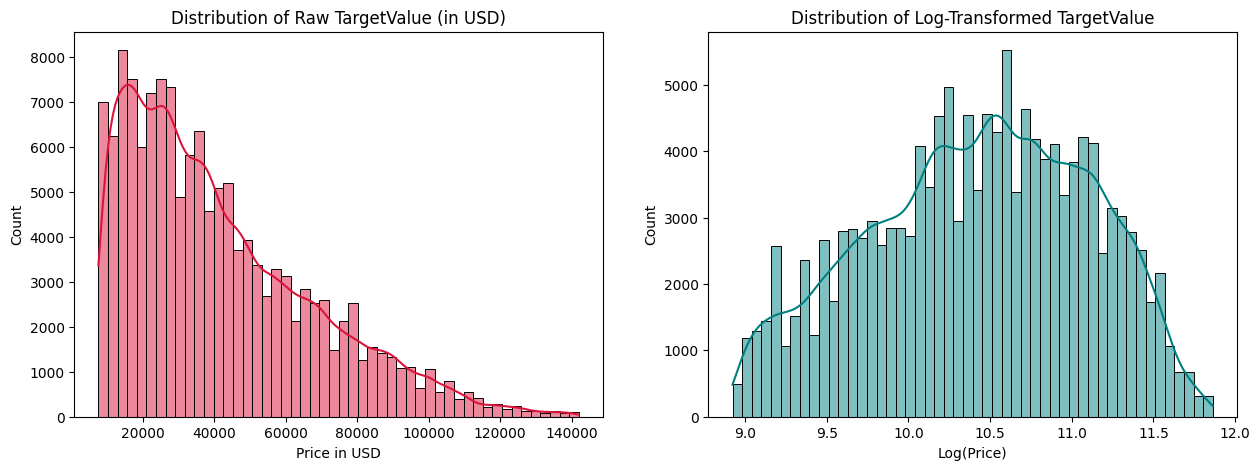

In [16]:
# Creating the chart layout window
# We are making this as a histogram (histplot)
# Why was histogram used and not anything else ?
# -> Histogram is perfect for this because it counts frequencies and shows the shape.
fig ,axes = plt.subplots(1, 2, figsize = (15 , 5))

# Making the first chart - This is the Raw Target value distribution
sns.histplot(
    y_raw,
    bins = 50,
    kde = True,
    ax = axes[0],
    color = 'crimson'
)
axes[0].set_title("Distribution of Raw TargetValue (in USD)")
# set_title() this adds the text on top of the chart
axes[0].set_xlabel("Price in USD")
# sets the horizontal label in the X axis
# There's also a set_ylabel but isn't used here for minimalism

# Making the second chart - This is the Logarithmic Transformed TargetValue
sns.histplot(
    y_log, 
    bins = 50, 
    kde = True, 
    ax=axes[1], 
    color='teal'
)
axes[1].set_title("Distribution of Log-Transformed TargetValue")
axes[1].set_xlabel("Log(Price)")

# Explaining the keaword arguments (**kwargs) in the seaborn histplot ->
# bins -> Essentially the number of bars in the histogram
# kde (Kernel Density Estimate) -> Essentially this draws the smooth line in front of the bars and helps infet the 'shape' of the graph
# color -> (here crimson and teal) -> This gives color to the graphs helps in visual identification

# The Universal Machine Learning Pipeline
> No matter which algorithm is used, every model follows these 5 structural steps:

1. **Prep Your Data** — Separate features `X` (the questions) from `y` (the answers)
2. **Import Your Model** — Grab the specific tool from the Scikit-Learn toolbox
3. **Instantiate the Model** — Create a brand new blank-slate model object
4. **Fit the Model** — Hand the robot `X` and `y` so it learns the patterns via `.fit(X, y)`
5. **Predict** — Give the robot the unseen exam paper and get guesses via `.predict(X_new)`

# Phase 4: Classical Machine Learning Model Exploration
## Model 1: Classic Linear Regression
We establish our first baseline machine learning model by fitting a classic linear regression algorithm to our fully numeric, imputed dataset.


In [17]:
# This Imports the Linear Regression from the Scikit Learn 
from sklearn.linear_model import LinearRegression

# Making an instance of the model
model_lr = LinearRegression()
print("Performing Linear Regression in the Dataset")

# Fitting the model
model_lr.fit(x_train_num , y_log)

# Asking the model for prediction
print("Linear Regression done successfully")
lr_log_prediction = model_lr.predict(x_test_num)

Performing Linear Regression in the Dataset
Linear Regression done successfully


In [18]:
# Here we convert the logarithmic numbers to true dollar values (essentially AntiLog of the same)
final_lr_prices = np.expm1(lr_log_prediction)

# Building the exact 2 column DataFrame required for the submission
lr_submission = pd.DataFrame({
    'TransactionID' : test_df['TransactionID'],
    'TargetValue' : final_lr_prices
})

# Save the DataFrame to CSV to overwriting the previous submission
lr_submission.to_csv(
    'submission.csv', 
    index = False
)
print("Linear Regression submission successfully and saved")

Linear Regression submission successfully and saved


## Model 2: Decision Tree Regressor
We introduce our third classical model using `DecisionTreeRegressor`. Unlike linear or distance models, a decision tree handles arbitrary categorical integer codes flawlessly by establishing recursive non-linear logical splits.


In [19]:
# We import the Decision Tree from the sklearn.tree module
from sklearn.tree import DecisionTreeRegressor as dtr

# Instantiating the model
# What is the role of the **kwargs here ?
# -> max_depth = This is like the number of levels of questions the tree can ask
# -> random_state = Its like a random seed makes the results reproducible
model_dt = dtr(
    max_depth = 10, 
    random_state = 42
)

# Fitting the model - Essentially Feeding the Model real values
model_dt.fit(x_train_num , y_log)
print("Decision Tree Model is being used")

# Predicting the model on the cleaned testing Dataset and getting the output in Log Transformed form
dt_log_prediction = model_dt.predict(x_test_num) 

# Converting the log values to real values using numpy's expm1 function that essentially does the Antilog
# Why is reconverting the log values to real values necessary ?
# -> This is so that the final submission resembles the required format
# -> Also if we do not re-transform the Log values the Error will shoot up drastically
dt_predict = np.expm1(dt_log_prediction)
print("Decision Tree Model applied successfully")

Decision Tree Model is being used
Decision Tree Model applied successfully


In [20]:
# Finally after getting the predicted value after the antilog function we generate a Pandas DataFrame from the same
dt_submission = pd.DataFrame({
    'TransactionID' : test_df["TransactionID"],
    'TargetValue' : dt_predict
})

# After formulation of the required DataFrame we formulate it into a Comma Separated Values (CSV) form suitable for submission
# This is so as to overwrite the previious submission
dt_submission.to_csv(
    'submission.csv',
    index = False
)
print("Decision Tree submission Ready")

Decision Tree submission Ready


## Model 3: Random Forest Regressor (Ensemble Group)
To overcome the overfitting and high-variance limitations of a single decision tree, we deploy our first ensemble method using a `RandomForestRegressor` with 100 estimators to average out prediction errors.


In [21]:
# Now we import the Random Forest from Scikit Learn Ensemble group
from sklearn.ensemble import RandomForestRegressor as rfr

# Instantiating the Model (All **kwargs explained) 
model_rf = rfr(
    n_estimators = 100, # This is like 100 Decision Trees voting together
    max_depth = 15, # This is like how far down each decision tree can go - more the number the overfitting chances are there , lesser the number the accuracy drops so a perfect middle ground of 15 is taken
    random_state = 42,# This is the seed value for unifomity
    n_jobs = -1 # This utilises all available CPU Cores on the Kaggle platform (Useful as ensemble methods in large datasets tend to take time)
)
print("Random Forest Model is being used here")

# FItting the model
model_rf.fit( x_train_num , y_log)

# Now prediction the output in Logartithmic form
rf_log_predict = model_rf.predict(x_test_num)

# Converting the Log Values to real values
rf_predict = np.expm1(rf_log_predict)
print("Random Forest Trained")

Random Forest Model is being used here
Random Forest Trained


In [22]:
# Finally after getting the predicted value after the antilog function we generate a Pandas DataFrame from the same
rf_submission = pd.DataFrame({
    'TransactionID' : test_df['TransactionID'],
    'TargetValue' : rf_predict
})

# And now finally we convert the DataFrame to csv for submission
rf_submission.to_csv(
    'submission.csv',
    index = False
)
print("Random Forest Submission Ready !!")

Random Forest Submission Ready !!


## Model 4. : HistGradientBoostingRegressor (Native Categorical Handling)
To shatter our performance bottleneck, we deploy a `HistGradientBoostingRegressor`. By explicitly declaring our 29 categorical fields via the `categorical_features` parameter, the model natively tracks text discrete splits and handles missing values without arbitrary numeric ordering bias.


In [23]:
from sklearn.ensemble import HistGradientBoostingRegressor as hgbr

# Find all category columns with cardinality > 255as HistGradientBoost (unlike Adaboost or XGBoost) has the ability to handle at maximum 255 unique values in categorical columns
cols_to_drop_hgb = []

for col in x_train.select_dtypes(include = 'category').columns:
    if x_train[col].nunique() > 255:
        cols_to_drop_hgb.append(col)

print(f"Columns with cardinality > 255 :-> {cols_to_drop_hgb}")
print(f"Dropping {len(cols_to_drop_hgb)} columns")

# Dropping the above mentioned columns
x_trn_drp = x_train.drop(columns = cols_to_drop_hgb)
x_test_drp = x_test.drop(columns = cols_to_drop_hgb)

# Now we instantiate the model
model_hgb = hgbr(
    categorical_features = 'from_dtype', # This essentially tells the M.L. algorithm to look up the dataframe columns if found to be category type treat them as categorical
    random_state = 42 # This is a uniformity seed value
)
print("Training the HistGradientBoostingRegressor Algorithm")

# Now we feed the model with the Training values
model_hgb.fit(
    x_trn_drp,
    y_log
)
print("HistGradient Boosting Regression Model trained successfully")

# Now we predict the final logarithmic values
hgb_log_predict = model_hgb.predict(x_test_drp)
print("The Logarithmic Prediction is out")

Columns with cardinality > 255 :-> ['TransactionDate', 'Spec_FullDescriptor', 'Spec_BaseClass']
Dropping 3 columns
Training the HistGradientBoostingRegressor Algorithm
HistGradient Boosting Regression Model trained successfully
The Logarithmic Prediction is out


In [24]:
# # We first convert the Logarithmic values to the True USD values
# hgb_predict = np.expm1(hgb_log_predict)

# # Now making the pandas dataframe for the submission
# hgb_submission = pd.DataFrame({
#     'TransactionID' : test_df['TransactionID'],
#     'TargetValue' : hgb_predict
# })

# # Now we convert the above DataFrame to a CSV and Submit it
# hgb_submission.to_csv(
#     'submission.csv',
#     index = False
# )
# print("HistGradientBoosting Submission Ready")

# Model 5: Advanced Ensembles & Linear Optimization

This section implements Gradient Boosting, Bagging, Extra Trees, SGD Regressors, and a Voting Regressor ensemble. The models are evaluated on preprocessed inputs to compare sequential tree updates, extreme randomization, and linear optimizations.

In [25]:
# from sklearn.ensemble import (
#     GradientBoostingRegressor,
#     BaggingRegressor,
#     ExtraTreesRegressor,
#     VotingRegressor
# )
# from sklearn.linear_model import SGDRegressor

# # Note: These models require preprocessed, fully numerical dense inputs (X_train_proc, X_valid_proc)
# # which we created using our ColumnTransformer.

# # 1. Gradient Boosting Regressor
# gbr = GradientBoostingRegressor(
#     n_estimators=100,
#     learning_rate=0.08,
#     max_depth=5,
#     random_state=42
# )
# gbr.fit(X_train_proc, y_train)
# print(f"GBR Val RMSE: {np.sqrt(mean_squared_error(y_val, gbr.predict(X_valid_proc))):.5f}")

# # 2. Extra Trees Regressor
# etr = ExtraTreesRegressor(
#     n_estimators=100,
#     max_depth=12,
#     random_state=42,
#     n_jobs=-1
# )
# etr.fit(X_train_proc, y_train)
# print(f"ETR Val RMSE: {np.sqrt(mean_squared_error(y_val, etr.predict(X_valid_proc))):.5f}")

# # 3. Bagging Regressor (using ETR as the base estimator)
# bagging = BaggingRegressor(
#     estimator=ExtraTreesRegressor(max_depth=8, random_state=42, n_jobs=-1),
#     n_estimators=10,
#     max_samples=0.8,
#     random_state=42,
#     n_jobs=-1
# )
# bagging.fit(X_train_proc, y_train)
# print(f"Bagging Val RMSE: {np.sqrt(mean_squared_error(y_val, bagging.predict(X_valid_proc))):.5f}")

# # 4. Stochastic Gradient Descent (SGD) Regressor
# sgd = SGDRegressor(
#     max_iter=1000,
#     alpha=0.0001,
#     penalty='l2',
#     random_state=42
# )
# sgd.fit(X_train_proc, y_train)
# print(f"SGD Val RMSE: {np.sqrt(mean_squared_error(y_val, sgd.predict(X_valid_proc))):.5f}")

# # 5. Voting Regressor Ensemble (Blends predictions of all estimators)
# voting_ensemble = VotingRegressor(
#     estimators=[
#         ('gbr', gbr),
#         ('etr', etr),
#         ('bagging', bagging)
#     ]
# )
# voting_ensemble.fit(X_train_proc, y_train)
# print(f"Voting Ensemble Val RMSE: {np.sqrt(mean_squared_error(y_val, voting_ensemble.predict(X_valid_proc))):.5f}")

## Model-6: HistGradientBoosting Regressor (Hyperparameter Tuned)

A tuned HistGradientBoosting Regressor designed to improve predictive performance while controlling overfitting. The model uses optimized training parameters, regularization, and leaf constraints to better capture complex relationships in the data.

This configuration aims to provide stronger generalization and more stable performance compared to the default model.

In [26]:
# from sklearn.ensemble import HistGradientBoostingRegressor
# from sklearn.model_selection import GridSearchCV

# # 1. Define the hyperparameter search space (Grid)
# param_grid = {
#     'learning_rate': [0.03, 0.1],
#     'max_depth': [7, 10],
#     'min_samples_leaf': [15, 30]
# }

# # 2. Instantiate the base estimator with native categorical detection
# hgb_base = HistGradientBoostingRegressor(
#     categorical_features='from_dtype',
#     l2_regularization=0.1,
#     random_state=42
# )

# # 3. Setup GridSearchCV (Evaluates all 8 combinations using 3-fold cross-validation)
# hgb_grid_search = GridSearchCV(
#     estimator=hgb_base,
#     param_grid=param_grid,
#     cv=3,
#     scoring='neg_root_mean_squared_error',
#     n_jobs=-1,
#     verbose=1
# )

# # 4. Run the Grid Search on the log target
# print("Running GridSearchCV for HistGradientBoostingRegressor...")
# hgb_grid_search.fit(x_trn_drp, y_log)

# print(f"Best Hyperparameters: {hgb_grid_search.best_params_}")
# print(f"Best CV RMSE: {hgb_grid_search.best_score_:.5f}")

# # 5. Predict using the best estimator found
# best_hgb = hgb_grid_search.best_estimator_
# hgb_tuned_log_preds = best_hgb.predict(x_test_drp)
# hgb_tuned_preds = np.expm1(hgb_tuned_log_preds)
# print("Tuned HistGradientBoostingRegressor predictions saved.")

In [27]:
# # Here we creaate the HistGradBoosting submissiion dataframe
# hgb_v2_submission = pd.DataFrame({
#     'TransactionID' : test_df['TransactionID'],
#     'TargetValue' : hgb_v2_predict
# })
# hgb_v2_submission.to_csv(
#     'submission.csv',
#     index = False
# )
# print(f"Tuned HGB submission is ready\nThe Results are like this ->\n{hgb_v2_submission.head()}")

## Model-7: Extreme Gradient Boosting (XGBoost) - Default Configuration

This model uses XGBoost Regressor, a powerful gradient boosting algorithm widely recognized for its strong performance on structured and tabular datasets. Prior to training, categorical features were converted to the `category` datatype to leverage XGBoost's native categorical feature support.

The model combines efficient histogram-based boosting, regularization, and feature sampling techniques to capture complex patterns while maintaining good generalization performance.

In [28]:
# Now using XGBoost on the same 
import xgboost as xgb

# Converting the NaN values in the categorical columns to category types
# Why is converting into category datatype required ?
# -> This is so because non numerid (int64 or float64) values are considered as an object according to Numpy's Conventions , however XGboost doesnt understand object categpry owing to which we have to use a neutral category column
for col in categorical_cols:
    x_train[col] = x_train[col].astype('category')
    x_test[col] = x_test[col].astype('category')
print("Dtypes are fixed for NaN in categorical columns")

# Instantiating the Model
model_xgb = xgb.XGBRegressor(
    n_estimators = 1000, # Number of Trees to build here
    learning_rate = 0.03,  # This is the learning rate this essentially dictates as to how much a tree can essentially contribute
    max_depth = 8, # This is essentailly the maximum depth of every tree 
    subsample = 0.8,  # This is the percentage of the rows the model can essentially see in making its predictions 
    colsample_bytree = 0.8,  # This is the number of features a modul can essentially inculcate in it - here its 80% of the features
    reg_lambda = 1.5, # This is the Ridge style regularuization that essentailly adds the penalty term
    reg_alpha = 0.1, # This is the Lasso style regularuzaton that adds the penalty term
    tree_method = 'hist', # Histogram based tree construction is used here
    enable_categorical = True, # This allows the Model to directly handle the category datatypes effectively
    random_state = 42, # Controls randomness.
    n_jobs = -1 # This uses all avaliable CPU cores
)
print("Training XGBoost")
model_xgb.fit(
    x_train,
    y_log
)
print("XGBoost Trained!!")

xgb_log_predict = model_xgb.predict(x_test)
xgb_predict = np.expm1(xgb_log_predict)
print("Predictions given by XGBoost are out")

Dtypes are fixed for NaN in categorical columns
Training XGBoost
XGBoost Trained!!
Predictions given by XGBoost are out


In [29]:
# FInally making the DataFrame and the CSV for the submission
xg_subm = pd.DataFrame({
    'TransactionID' : test_df['TransactionID'],
    'TargetValue' : xgb_predict
})
print("XGradboost (Extreme Gradient Boosting) submission dataframe is ready !!")

# And now we convert to CSV
xg_subm.to_csv(
    'submission.csv',
    index = False
)
print(f"XGradboost CSV result is here :->\n{xg_subm.head()}")

XGradboost (Extreme Gradient Boosting) submission dataframe is ready !!
XGradboost CSV result is here :->
   TransactionID   TargetValue
0        1139307  58914.753906
1        1139419  66021.171875
2        1139482  35267.316406
3        1139522  18462.712891
4        1139684  12393.366211


## Model-8: Extreme Gradient Boosting (XGBoost) - Hyperparameter Tuned

This model is a hyperparameter-tuned version of the baseline XGBoost Regressor, developed to improve predictive accuracy and generalization. The tuning process increases model learning capacity while incorporating additional regularization and split-control mechanisms to reduce overfitting.

The resulting configuration aims to achieve a better balance between model complexity and robustness, enabling improved performance on unseen data while retaining XGBoost's efficiency and scalability.

In [30]:
# import xgboost as xgb
# from sklearn.model_selection import GridSearchCV

# # 1. Define the hyperparameter search grid
# xgb_param_grid = {
#     'learning_rate': [0.03, 0.05],
#     'max_depth': [6, 8],
#     'min_child_weight': [3, 5],
#     'gamma': [0.0, 0.1]
# }

# # 2. Instantiate base XGBRegressor with stable parameters
# xgb_base = xgb.XGBRegressor(
#     n_estimators=1400,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     reg_lambda=1.5,
#     reg_alpha=0.1,
#     tree_method='hist',
#     enable_categorical=True,
#     random_state=42,
#     n_jobs=-1
# )

# # 3. Setup GridSearchCV with 3-fold Cross-Validation
# xgb_grid_search = GridSearchCV(
#     estimator=xgb_base,
#     param_grid=xgb_param_grid,
#     cv=3,
#     scoring='neg_root_mean_squared_error',
#     n_jobs=-1,
#     verbose=1
# )

# # 4. Fit the Grid Search
# print("Running GridSearchCV for XGBRegressor...")
# xgb_grid_search.fit(X_train, y_log)

# print(f"Best XGB Hyperparameters: {xgb_grid_search.best_params_}")
# print(f"Best CV RMSE: {-xgb_grid_search.best_score_:.5f}")

# # 5. Predict using the best model
# best_xgb = xgb_grid_search.best_estimator_
# xgb_tuned_log_preds = best_xgb.predict(X_test)
# xgb_tuned_preds = np.expm1(xgb_tuned_log_preds)
# print("Tuned XGBoost predictions saved.")

In [31]:
# # Converting the Results so formed into a DataFrame format
# xgb_v2_subm = pd.DataFrame({
#     'TransactionID' : test_df['TransactionID'],
#     'TargetValue' : xgb_v2_res
# })

# # Now Converting this to a CSV we have
# xgb_v2_subm.to_csv(
#     'submission.csv',
#     index = False
# )
# print(f"The Tuned Predictions for the XGBoost submission are out :->\n{xgb_v2_subm.head()}")

# Phase 5: Feature Engineering and Dataset Preparation

Feature engineering was performed to create additional domain-driven features from existing machine attributes, helping models better capture patterns related to equipment age, usage intensity, depreciation, and operational characteristics.

Five new features were generated: `machine_age`, `hours_per_year`, `is_modern`, `high_usage`, and `age_bucket`. These features were designed to provide richer information about machine condition and utilization beyond the original dataset.

The objective was to improve model performance by introducing meaningful predictors that better represent real-world factors influencing machine value.

After feature engineering, the feature matrices were rebuilt by removing non-predictive columns such as `TransactionID` and the target variable `TargetValue`, preventing data leakage during model training.

Finally, categorical features were converted to the `category` datatype to ensure compatibility with XGBoost's native categorical feature handling and maintain consistency between the training and testing datasets.

In [32]:
# # We do feature engineering here 
# # Our goal is to optimize on the dataframe and we do so by adding four extra columns

# def feature_engineering(df):
#     df = df.copy()
    
#     # Feature 1 → Machine Age
#     # Essentially here we take 2013 as a baseline and calculate the age of the machine relative to it
#     df['machine_age'] = 2013 - df['ManufactureYear']
    
#     # Feature 2 → Hours per Year
#     # Essentially here we calculate the hours per year a machine operates
#     df['hours_per_year'] = (
#         df['OperationalHoursMeter'] / (df['machine_age'] + 1)  # We add 1 because otherwise it will be a division by zero for a new machine built in 2013
#     )
    
#     # Feature 3 → Is Modern
#     # Here we check whether the machine is built after 2000 or not and if it is then we convert to an integer
#     df['is_modern'] = (df['ManufactureYear'] >= 2000).astype(int)
    
#     # Feature 4 → High Usage
#     # Here we check whether 
#     df['high_usage'] = (df['OperationalHoursMeter'] > 10000).astype(int)
    
#     # Feature 5 → Age Bucket
#     # We divide the age braces into 5 cartgeories
#     # 0 to 5 years
#     # 5 to 10 years
#     # 10 to 20 years
#     # 20 to 50 years
#     #  50 +  years
#     df['age_bucket'] = pd.cut(
#         df['machine_age'],
#         bins = [0, 10, 20, 50, 100], # These are the bins
#         labels = [0, 1, 2, 3] # These are the categories
#     ).astype(float)
    
#     return df

# # Here apply this function
# train_df_clean = feature_engineering(train_df_clean)
# test_df_clean = feature_engineering(test_df_clean)
# print("Feature Engineering Has been applied !!!")
# print(f"Added New features\nNew shape of training data is :-> {train_df_clean.shape}")

In [33]:
# # Rebuilding the Feature Matrix (F.E.M) after the FE step
# # Why is this necessary ?
# # -> Considering the model to be a student giving an exam , in an exam ideally the student must not be allowed to look into the answers so as to make a reliable guess
# # -> Henceforth our FEM removes the TransactionID and TargetValue columns from the Training Dataset are removed
# x_train = train_df_clean.drop(columns=['TransactionID', 'TargetValue'])
# x_test = test_df_clean.drop(columns=['TransactionID'])
# print(f"x_train shape: {x_train.shape}")
# print(f"x_test shape:  {x_test.shape}")

# # Fixing the Dataset after FE step
# # Why do we need to fix ?
# #  -> It is because FE step induces extra essential columns into the training data which are of categorical type object
# #  -> Since XGBoost cannot understand object datatype we explicitly convert the same to category datatype
# for col in categorical_cols:
#     if col in x_train.columns:
#         x_train[col] = x_train[col].astype('category')
#         x_test[col] = x_test[col].astype('category')

# print("Dtypes fixed!")
# print(x_train.dtypes.value_counts())

## Model-9: Feature-Engineered XGBoost (Hyperparameter Tuned)

This model combines domain-driven feature engineering with a hyperparameter-tuned XGBoost Regressor to leverage both enriched feature representations and the predictive strength of gradient boosting. The engineered features provide additional information related to machine age, utilization patterns, and operational characteristics.

The objective was to evaluate whether these newly created features could improve predictive performance beyond the original dataset attributes while maintaining strong generalization through XGBoost's built-in regularization and categorical feature support.

This pipeline integrates data cleaning, feature engineering, dataset preparation, and tuned XGBoost training into a single end-to-end machine learning workflow for prediction and submission generation.

In [34]:
# # Here we run the XGBoost FE Model on top of it to capitalize on the feature engineering to optimize the score on Kaggle
# model_xgb_fe = xgb.XGBRegressor(
#     n_estimators = 1400, 
#     learning_rate = 0.03,
#     max_depth = 8,
#     subsample = 0.8,
#     colsample_bytree = 0.8,
#     reg_lambda = 1.5,
#     reg_alpha = 0.1,
#     min_child_weight = 5,
#     gamma = 0.1,
#     tree_method = 'hist',
#     enable_categorical = True,
#     random_state = 42,
#     n_jobs = -1
# )
# print("XGBoost with Feature Engineering Instantiated Properly")

# # We fit the Model on the Training data
# model_xgb_fe.fit(
#     x_train,
#     y_log
# )
# print("XG Boost FE is Ready")

# # We now predict the Logarithmic values and then convert them to real life values
# xgb_fe_log_predict = model_xgb_fe.predict(x_test)
# xgb_fe_predict = np.expm1(xgb_fe_log_predict)
# print("XGB FE Prediction successful")

In [35]:
# # Making our submission DataFrames here
# xgb_fe_df = pd.DataFrame({
#     'TransactionID' : test_df['TransactionID'],
#     'TargetValue' : xgb_fe_predict
# })
# print("Submission DataFrame is Ready")

# # Converting the same to a CSV comma separated value format
# xgb_fe_df.to_csv(
#     'submission.csv',
#     index = False
# )
# print(f"The CSV is ready !!\n{xgb_fe_df.head()}")

## Local Validation of Feature-Engineered XGBoost

A local validation framework was established to estimate model performance before final Kaggle submission. The dataset was split into training and validation subsets, allowing the model to be evaluated on previously unseen data and providing a more reliable measure of generalization performance.

The validation pipeline combined data cleaning, missing value imputation, feature engineering, and a tuned XGBoost model. This approach enabled objective model evaluation while assessing the contribution of the engineered features.

Model performance was measured using RMSLE, the competition's evaluation metric, ensuring that local validation results closely reflected expected leaderboard performance and helping reduce the risk of overfitting.

In [36]:
# Now along with Feature Engineering we will deploy explicit validation set phase for the same
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Split the training data into training and validation data
x_tr ,x_val , y_tr , y_val = train_test_split(
    x_train , 
    y_log ,
    test_size = 0.2, # This essentially means that we are giving 80 % of the Training Data into Explicit Training and 20 % into validation
    random_state = 42 # This is a uniformiy seed value
)

# What is Validation set ?
# -> Validation set is essentially a simulation of the Test Dataset to evaluate and improve upon the model performance
print("Successfully split the Input Dataset into Training and Validation Datasets")
print(f"Training Set -> {x_tr.shape}")
print(f"Validation Set -> {x_val.shape}")

Successfully split the Input Dataset into Training and Validation Datasets
Training Set -> (110960, 33)
Validation Set -> (27741, 33)


In [37]:
# model_xgb_val = xgb.XGBRegressor(
#     n_estimators = 1500,
#     learning_rate = 0.02,
#     max_depth = 10,
#     subsample = 0.8,
#     colsample_bytree = 0.8,
#     reg_lambda = 1.5,
#     reg_alpha = 0.1,
#     min_child_weight = 5,
#     gamma = 0.1,
#     tree_method = 'hist',
#     enable_categorical = True,
#     random_state = 42,
#     n_jobs = -1
# )
# print("Instantiated the XGBoost model with Validation\n")

# # Now unlike fitting on full data we fit on the explicit training data we made
# model_xgb_val.fit(
#     x_tr,
#     y_tr
# )

# # Now we validate on the 20% get the result in the log form 
# val_log_preds = model_xgb_val.predict(x_val)
# print("Validated and Tuned XGBoost is ready\nThis model's predictions are out")

# # Local Validation here (RMSLE)
# rmsle = np.sqrt(
#     mean_squared_error(y_val ,val_log_preds)
# )
# print(f"Local Validation RMSLE -> {round(rmsle , 5)}")

In [38]:
# # Now Training on Full Data for submission
# model_xgb_v3 = xgb.XGBRegressor(
#     n_estimators = 1500,
#     learning_rate = 0.02,
#     max_depth = 10,
#     subsample = 0.8,
#     colsample_bytree = 0.8,
#     reg_lambda = 1.5,
#     reg_alpha = 0.1,
#     min_child_weight = 5,
#     gamma = 0.1,
#     tree_method = 'hist',
#     enable_categorical = True,
#     random_state = 42,
#     n_jobs = -1
# )
# print("Instantiated Model Here")

# # Fitting on full training data
# model_xgb_v3.fit(
#     x_train,
#     y_log
# )
# print("Model Trained here")

# # Now we predict on Test Data first ysing the given conditions
# pred_log_res = model_xgb_v3.predict(
#     x_test
# )
# pred_res = np.expm1(pred_log_res)
# print("Model Predictions are out")

In [39]:
# # making our submission here as a DF format
# xgb_v3df = pd.DataFrame({
#     'TransactionID' : test_df['TransactionID'],
#     'TargetValue' : pred_res
# })
# print(f"The Submission DF is ready\n{xgb_v3df.head()}")

# # Making the submission here as a CSV format
# xgb_v3df.to_csv(
#     'submission.csv',
#     index = False
# )
# print("The Final CSV is Ready !!")

## Model-9: XGBoost with Extended Feature Engineering

This model extends the previous feature engineering pipeline by incorporating additional temporal and wear-related features derived from transaction dates and machine utilization patterns. These new features were designed to provide deeper insight into equipment condition, usage behavior, and potential market trends.

A total of ten engineered features were used, combining the original feature set with new indicators related to sale timing, seasonal effects, equipment wear, and utilization intensity.

The objective was to determine whether these additional domain-driven features could further improve XGBoost's predictive performance beyond the earlier feature-engineered models.

In [40]:
# # A new feature Engineering function
# def feature_engineering(df):
#     df = df.copy()

#     # Existing F.E
#     df['machine_age'] = 2013 - df['ManufactureYear']
#     df['hours_per_year'] = df['OperationalHoursMeter'] / (df['machine_age'] + 1)
#     df['is_modern'] = (df['ManufactureYear'] >= 2000).astype(int)
#     df['high_usage'] = (df['OperationalHoursMeter'] > 10000).astype(int)
#     df['age_bucket'] = pd.cut(
#         df['machine_age'],
#         bins = [0, 10, 20, 50, 100],
#         labels = [0, 1, 2, 3]
#     ).astype(float)

#     # New F.E. features
#     # sale date features
#     df['sale_year'] = pd.to_datetime(
#         df['TransactionDate'] 
#     ).dt.year
#     df['sale_month'] = pd.to_datetime(
#          df['TransactionDate']   
#     ).dt.month

#     # is it the end of the year auction
#     df['is_december'] = (df['sale_month'] == 12).astype(int)

#     # deciding the wear index as the age and usage intensity product
#     # Wear index → age × usage intensity
#     df['wear_index'] = df['machine_age'] * df['hours_per_year']

#     # checking wheter the machine has a low usage or a high usage
#     df['low_usage'] = (df['OperationalHoursMeter'] < 1000).astype(int)

#     return df

# # Adding the New features to the functions
# train_df_clean = feature_engineering(train_df_clean)
# test_df_clean = feature_engineering(test_df_clean)

# # Displaying the Result
# print(f"New Shape -> {train_df_clean.shape}")

In [41]:
# # Now we rebuild the feaure matrix and then convert to the category data type
# x_train = train_df_clean.drop(columns = ['TransactionID' ,'TargetValue'])
# x_test = test_df_clean.drop(columns = ['TransactionID'])

# # Displaying the same
# print(f"X Train shape -> {x_train.shape}")
# print(f"X Test shape -> {x_test.shape}")

# # Now we fix the datatypes after rebuilding
# for col in categorical_cols:
#     if col in x_train.columns:
#         x_train[col] = x_train[col].astype('category')
#         x_test[col] = x_test[col].astype('category')

# print(f"Datatypes have been fixed\n{x_train.dtypes.value_counts()}")

In [42]:
# # Instantiate the model
# model_xgb_fe2 = xgb.XGBRegressor(
#     n_estimators=1800,
#     learning_rate=0.025,
#     max_depth=8,
#     subsample=0.85,
#     colsample_bytree=0.85,
#     reg_lambda=1.5,
#     reg_alpha=0.1,
#     min_child_weight=4,
#     gamma=0.05,
#     tree_method='hist',
#     enable_categorical=True,
#     random_state=42,
#     n_jobs=-1
# )
# print("New XGB Regressor model is out")

# # Validate first the new model
# X_tr, X_val, y_tr, y_val = train_test_split(
#     x_train, y_log,
#     test_size=0.2,
#     random_state=42
# )
# model_xgb_fe2.fit(X_tr, y_tr)
# val_preds = model_xgb_fe2.predict(X_val)
# rmsle = np.sqrt(mean_squared_error(y_val, val_preds))
# print(f"Local RMSLE → {rmsle:.5f}")

In [43]:
# # For now the submission we now have to retrain the model on full training data
# model_xgb_fe2 = xgb.XGBRegressor(
#     n_estimators=1800,
#     learning_rate=0.025,
#     max_depth=8,
#     subsample=0.85,
#     colsample_bytree=0.85,
#     reg_lambda=1.5,
#     reg_alpha=0.1,
#     min_child_weight=4,
#     gamma=0.05,
#     tree_method='hist',
#     enable_categorical=True,
#     random_state=42,
#     n_jobs=-1
# )
# print("The Instantiated and Validated model is ready\n")

# # Fitting the same on 100% of training data
# # Retrain on 100% data
# model_xgb_fe2.fit(x_train, y_log)

# # Predicting the said values 
# xgb_fe2_preds = np.expm1(
#     model_xgb_fe2.predict(x_test)
# )

# # Sanity check
# print(f"Mean: ${xgb_fe2_preds.mean():,.0f}")
# print(f"Min:  ${xgb_fe2_preds.min():,.0f}")
# print(f"Max:  ${xgb_fe2_preds.max():,.0f}")

In [44]:
# # Making the submission DataFrame
# xgb_feat_sub = pd.DataFrame({
#     'TransactionID': test_df['TransactionID'],
#     'TargetValue': xgb_fe2_preds
# })
# xgb_feat_sub.to_csv('submission.csv', index=False)
# print("Submission ready!")

## Model-10: Extended Feature Engineering + Aggressively Tuned XGBoost

This model builds upon previous feature engineering efforts by introducing additional temporal, lifecycle, and utilization-based features designed to capture more complex patterns in machine depreciation and resale value. The expanded feature set provides richer representations of equipment age, usage behavior, seasonality, and machine condition.

These engineered features were combined with a higher-capacity, aggressively tuned XGBoost model to better exploit feature interactions and nonlinear relationships within the dataset.

The objective was to evaluate whether the combination of extended feature engineering and increased model complexity could further improve predictive performance and establish a new benchmark leaderboard score.

In [45]:
# def feature_engineering(df):
#     df = df.copy()
    
#     # Columns added in FE1
#     df['machine_age'] = 2013 - df['ManufactureYear']
#     df['hours_per_year'] = df['OperationalHoursMeter'] / (df['machine_age'] + 1)
#     df['is_modern'] = (df['ManufactureYear'] >= 2000).astype(int)
#     df['high_usage'] = (df['OperationalHoursMeter'] > 10000).astype(int)
#     df['age_bucket'] = pd.cut(
#         df['machine_age'],
#         bins = [0, 10, 20, 50, 100],
#         labels = [0, 1, 2, 3]
#     ).astype(float)

#     # Columns added in FE2
#     df['sale_year'] = pd.to_datetime(
#         df['TransactionDate'] 
#     ).dt.year
#     df['sale_month'] = pd.to_datetime(
#          df['TransactionDate']   
#     ).dt.month
#     df['is_december'] = (df['sale_month'] == 12).astype(int)
#     df['wear_index'] = df['machine_age'] * df['hours_per_year']
#     df['low_usage'] = (df['OperationalHoursMeter'] < 1000).astype(int)

#     # New(EST) columns we'll add now
#     # Sale quarters
#     df['sale_quarters'] = pd.to_datetime(
#         df['TransactionDate']
#     ).dt.quarter

#     # Checking whether the machine is super old or not
#     df['is_vintage'] = (df['machine_age'] > 30).astype(int)

#     # Checking whether the machine is super new or not
#     df['is_young'] = (df['machine_age'] < 5).astype(int)

#     # Usage Ratio being normalised here 
#     df['usage_ratio'] = (
#         df['OperationalHoursMeter'] /
#         (df['OperationalHoursMeter'].max() + 1)
#     )

#     # Age x Modern combined
#     df['age_modern'] = df['machine_age'] * df['is_modern']

#     return df

# print("Feature Engineering 3rd Iterations is successful here !!!")

# # Adding the New features to the functions
# train_df_clean = feature_engineering(train_df_clean)
# test_df_clean = feature_engineering(test_df_clean)

# # Displaying the Result
# print(f"New Training Dataset shape -> {train_df_clean.shape}")

In [46]:
# # Now we rebuild the feaure matrix and then convert to the category data type
# x_train = train_df_clean.drop(columns = ['TransactionID' ,'TargetValue'])
# x_test = test_df_clean.drop(columns = ['TransactionID'])

# # Displaying the same
# print(f"X Train shape -> {x_train.shape}")
# print(f"X Test shape -> {x_test.shape}")

# # Now we fix the datatypes after rebuilding
# for col in categorical_cols:
#     if col in x_train.columns:
#         x_train[col] = x_train[col].astype('category')
#         x_test[col] = x_test[col].astype('category')

# print(f"Datatypes have been fixed\n{x_train.dtypes.value_counts()}")

In [47]:
# # Running the XGBoost Again - This is in version with further FE and with more validation
# model_xgb_v3 = xgb.XGBRegressor(
#     n_estimators = 2000,       # more trees
#     learning_rate = 0.02,      # slower
#     max_depth = 9,             # deeper
#     subsample = 0.85,
#     colsample_bytree = 0.85,
#     reg_lambda = 1.0,
#     reg_alpha = 0.05,
#     min_child_weight = 3,
#     gamma = 0.05,
#     tree_method = 'hist',
#     enable_categorical = True,
#     random_state = 42,
#     n_jobs = -1
# )
# print("Instantiated the model successfully !!!")

# # Here we validate the model as validation essentially helps us to decide 
# X_tr, X_val, y_tr, y_val = train_test_split(
#     x_train, y_log,
#     test_size = 0.2,
#     random_state = 42
# )

# # Fitting the model on Validation Data
# model_xgb_v3.fit(X_tr, y_tr)
# print("Our Sample model has been trained")

# # Now prediction phase 
# val_pred = model_xgb_v3.predict(X_val)
# rmsle = np.sqrt(mean_squared_error(y_val, val_pred))
# print(f"Local RMSLE → {rmsle:.5f}")

In [48]:
# # Here we do the same trick
# # We re-train the validated model on full training dataset here
# # We essentially keep the same keyword arguments as they have yeilded best returns on the validated model
# model_xgb_fe3 = xgb.XGBRegressor(
#     n_estimators = 2000,       # more trees
#     learning_rate = 0.02,      # slower
#     max_depth = 9,             # deeper
#     subsample = 0.85,
#     colsample_bytree = 0.85,
#     reg_lambda = 1.0,
#     reg_alpha = 0.05,
#     min_child_weight = 3,
#     gamma = 0.05,
#     tree_method = 'hist',
#     enable_categorical = True,
#     random_state = 42,
#     n_jobs = -1
# )
# print("Instantiated the model successfully !!!")

# # We fit the model here
# model_xgb_fe3.fit(
#     x_train,
#     y_log
# )
# print("Model has been trained on the training Dataset here !!!")

# # Predicting the outcome
# model_xgb_otc = np.expm1(
#     model_xgb_fe3.predict(
#         x_test
#     )
# )
# print("The Model has predicted the values successfully !!!")

In [49]:
# # Making the Final Dataset submission
# xgb_fe3_sub = pd.DataFrame({
#     'TransactionID' : test_df['TransactionID'],
#     'TargetValue' : model_xgb_otc
# })
# print("The Submission DataFrame is Ready")

# # Converting the dataset to a CSV
# xgb_fe3_sub.to_csv(
#     'submission.csv',
#     index = False
# )
# print(f"The Submission CSV is Ready\n{xgb_fe3_sub.head()}")

## Model-11: Weighted Ensemble of Tuned XGBoost Models

This model combines the predictions of two independently trained and hyperparameter-tuned XGBoost models using a weighted averaging strategy. The final prediction is generated by assigning a weight of 90% to the primary model and 10% to the secondary model.

The objective was to improve prediction stability and generalization by leveraging the strengths of both models while giving greater influence to the stronger-performing submission. Such ensembles often outperform individual models by reducing variance and capturing complementary predictive signals.

This experiment evaluates whether a weighted blend of multiple XGBoost models can achieve better leaderboard performance than either model independently.

In [50]:
# # Ensembling the models here -> Version 33 and the Version 32 (The Versions are the Kaggle's savepoint order)
# # This is to hereby check whether the columns match each other perfectly or not
# assert (
#     xgb_feat_sub['TransactionID']
#     ==
#     xgb_fe3_sub['TransactionID']
# ).all()

# print("Rows aligned successfully!")

In [51]:
# # Copying the version 33 here ->
# ensemble_sub = xgb_fe3_sub.copy()

# # Now making the Ensemble DF
# ensemble_sub['TargetValue'] = (
#     0.9 * xgb_fe3_sub['TargetValue'] + 0.1 * xgb_feat_sub['TargetValue']
# )
# print(f"We have assembled the Ensembled DF successfully\n{ensemble_sub.head()}")

# # Now we convert the DF to CSV format here
# ensemble_sub.to_csv(
#     'submission.csv',
#     index = False
# )
# print("Ensemble Submission is Ready")

In [52]:
# # Now here for the next submission we will do the ensemble of the v34 with the v33
# ensemble_two_sub = ensemble_sub.copy()

# ensemble_two_sub['TargetValue'] = (
#     0.95 * xgb_fe3_sub['TargetValue'] + 0.05 * ensemble_sub['TargetValue']
# )
# print(f"We have assembled the Ensembled Df successfully\n{ensemble_two_sub.head()}")

# # Now we convert the DF to CSV format here
# ensemble_sub.to_csv(
#     'submission.csv',
#     index = False
# )
# print("The Second ensemble Submission is Ready")

## Model-12: Feature-Engineered XGBoost (Version 4)

This model extends the previous feature engineering pipeline by introducing additional transformations designed to better capture nonlinear relationships and machine utilization patterns. New features such as `log_hours` and `machine_age_sq` were added to represent operating hours on a logarithmic scale and model nonlinear age-related effects.

The expanded feature set combines temporal, usage-based, lifecycle, and interaction features to provide a richer representation of machine characteristics. These engineered variables aim to expose patterns that may not be directly observable from the original dataset attributes.

The objective of this experiment was to evaluate whether the enhanced feature space could further improve the performance of the tuned XGBoost model and achieve a lower prediction error than previous feature engineering iterations.

In [53]:
# # Adding more features into the dataset
# def feature_engineering(df):
#     df = df.copy()

#     # Columns added in FE1
#     df['machine_age'] = 2013 - df['ManufactureYear']
#     df['hours_per_year'] = df['OperationalHoursMeter'] / (df['machine_age'] + 1)
#     df['is_modern'] = (df['ManufactureYear'] >= 2000).astype(int)
#     df['high_usage'] = (df['OperationalHoursMeter'] > 10000).astype(int)
#     df['age_bucket'] = pd.cut(
#         df['machine_age'],
#         bins = [0, 10, 20, 50, 100],
#         labels = [0, 1, 2, 3]
#     ).astype(float)

#     # Columns added in FE2
#     df['sale_year'] = pd.to_datetime(
#         df['TransactionDate'] 
#     ).dt.year
#     df['sale_month'] = pd.to_datetime(
#          df['TransactionDate']   
#     ).dt.month
#     df['is_december'] = (df['sale_month'] == 12).astype(int)
#     df['wear_index'] = df['machine_age'] * df['hours_per_year']
#     df['low_usage'] = (df['OperationalHoursMeter'] < 1000).astype(int)

#     # Columns added in FE3
#     df['sale_quarters'] = pd.to_datetime(
#         df['TransactionDate']
#     ).dt.quarter
#     df['is_vintage'] = (df['machine_age'] > 30).astype(int)
#     df['is_young'] = (df['machine_age'] < 5).astype(int)
#     df['usage_ratio'] = (
#         df['OperationalHoursMeter'] /
#         (df['OperationalHoursMeter'].max() + 1)
#     )
#     df['age_modern'] = df['machine_age'] * df['is_modern']

#     # New Columns added now here
#     # Add to feature_engineering function:
#     df['log_hours'] = np.log1p(df['OperationalHoursMeter'])
#     df['machine_age_sq'] = df['machine_age'] ** 2

#     return df

# print("New FE codes written here")

# # Adding the New features to the functions
# train_df_clean = feature_engineering(train_df_clean)
# test_df_clean = feature_engineering(test_df_clean)

# # Displaying the Result
# print(f"New Training Dataset shape -> {train_df_clean.shape}")

In [54]:
# # Now we rebuild the feaure matrix and then convert to the category data type
# x_train = train_df_clean.drop(columns = ['TransactionID' ,'TargetValue'])
# x_test = test_df_clean.drop(columns = ['TransactionID'])

# # Displaying the same
# print(f"X Train shape -> {x_train.shape}")
# print(f"X Test shape -> {x_test.shape}")

# # Now we fix the datatypes after rebuilding
# for col in categorical_cols:
#     if col in x_train.columns:
#         x_train[col] = x_train[col].astype('category')
#         x_test[col] = x_test[col].astype('category')

# print(f"Datatypes have been fixed\n{x_train.dtypes.value_counts()}")

In [55]:
# # Running the XGBoost Again - This is in version with further FE and with more validation
# model_xgb_v4 = xgb.XGBRegressor(
#     n_estimators = 2000,
#     learning_rate = 0.02,
#     max_depth = 9,
#     subsample = 0.85,
#     colsample_bytree = 0.85,
#     reg_lambda = 1.0,
#     reg_alpha = 0.05,
#     min_child_weight = 3,
#     gamma = 0.05,
#     tree_method = 'hist',
#     enable_categorical = True,
#     random_state = 42,
#     n_jobs = -1,
#     verbosity = 2
# )
# print("Instantiated the model successfully !!!")

# # Here we validate the model as validation essentially helps us to decide 
# X_tr, X_val, y_tr, y_val = train_test_split(
#     x_train, y_log,
#     test_size = 0.2,
#     random_state = 42
# )

# # Fitting the model on Validation Data
# model_xgb_v4.fit(X_tr, y_tr)
# print("Our Sample model has been trained")

# # Now prediction phase 
# val_pred = model_xgb_v4.predict(X_val)
# rmsle = np.sqrt(mean_squared_error(y_val, val_pred))
# print(f"Local RMSLE → {rmsle:.5f}")

In [56]:
# my_model_xgb_v4 = xgb.XGBRegressor(
#     n_estimators = 2000,
#     learning_rate = 0.02,
#     max_depth = 9,
#     subsample = 0.85,
#     colsample_bytree = 0.85,
#     reg_lambda = 1.0,
#     reg_alpha = 0.05,
#     min_child_weight = 3,
#     gamma = 0.05,
#     tree_method = 'hist',
#     enable_categorical = True,
#     random_state = 42,
#     n_jobs = -1,
#     verbosity = 2
# )
# print("Instantiated the model successfully !!!")

# # Now we have this model fit on the entire training data
# my_model_xgb_v4.fit(
#     x_train,
#     y_log
# )
# print("Model has been trained on the training Dataset here !!!")

# # Predicting the outcome
# out_sel_pred = np.expm1(
#     my_model_xgb_v4.predict(
#         x_test
#     )
# )
# print("The Model has predicted the values successfully !!!")

In [57]:
# # Converting the DataFrame here ->
# model_xgb_v4df = pd.DataFrame({
#     'TransactionID' : test_df['TransactionID'],
#     'TargetValue' : out_sel_pred
# })
# print("The Final dataframe is made ->")

# # Converting to the CSV here ->
# model_xgb_v4df.to_csv(
#     'submission.csv',
#     index = False
# )
# print(f"The Final CSV format is out\n{model_xgb_v4df.head()}")

## Model-13: Feature-Engineered XGBoost (Version 5)

This model introduces a revised feature engineering pipeline that expands upon previous iterations with additional calendar-based, auction-specific, and machine lifecycle features. The newly engineered variables capture information such as auction timing, seasonal behavior, machine age at sale, utilization categories, and recent market activity.

Several experimental features from the previous version were removed after demonstrating limited contribution to model performance, resulting in a more refined and targeted feature set. The updated engineering strategy focuses on extracting stronger predictive signals while reducing unnecessary feature complexity.

The objective of this experiment was to determine whether these revised domain-driven features could improve XGBoost's ability to model equipment valuation patterns and achieve better predictive performance than earlier feature engineering versions.

In [58]:
# # Adding more features into the dataset
# def feature_engineering(df):
#     df = df.copy()

#     # Columns added in FE1
#     df['machine_age'] = 2013 - df['ManufactureYear']
#     df['hours_per_year'] = df['OperationalHoursMeter'] / (df['machine_age'] + 1)
#     df['is_modern'] = (df['ManufactureYear'] >= 2000).astype(int)
#     df['high_usage'] = (df['OperationalHoursMeter'] > 10000).astype(int)
#     df['age_bucket'] = pd.cut(
#         df['machine_age'],
#         bins = [0, 10, 20, 50, 100],
#         labels = [0, 1, 2, 3]
#     ).astype(float)

#     # Columns added in FE2
#     df['sale_year'] = pd.to_datetime(
#         df['TransactionDate'] 
#     ).dt.year
#     df['sale_month'] = pd.to_datetime(
#          df['TransactionDate']   
#     ).dt.month
#     df['is_december'] = (df['sale_month'] == 12).astype(int)
#     df['wear_index'] = df['machine_age'] * df['hours_per_year']
#     df['low_usage'] = (df['OperationalHoursMeter'] < 1000).astype(int)

#     # Columns added in FE3
#     df['sale_quarters'] = pd.to_datetime(
#         df['TransactionDate']
#     ).dt.quarter
#     df['is_vintage'] = (df['machine_age'] > 30).astype(int)
#     df['is_young'] = (df['machine_age'] < 5).astype(int)
#     df['usage_ratio'] = (
#         df['OperationalHoursMeter'] /
#         (df['OperationalHoursMeter'].max() + 1)
#     )
#     df['age_modern'] = df['machine_age'] * df['is_modern']

#     # Removed the FE4 (Commented the below part out as they objectively made the score somewhat worse)
#     # Add to feature_engineering function:
#     # df['log_hours'] = np.log1p(df['OperationalHoursMeter'])
#     # df['machine_age_sq'] = df['machine_age'] ** 2

#     # New Feature Engineering 4th Version (ReVamped version here)
#     # Getting the Week's Day here ->
#     df['sale_dayofweek'] = pd.to_datetime(
#         df['TransactionDate'] 
#     ).dt.dayofweek

#     # Getting whether the Auction is scheduled in a weekend or not in the form of binary integers
#     df['is_weekend_auction'] = (df['sale_dayofweek'] >= 5).astype(int)

#     # Getting the sale day of the year
#     df['sale_dayofyear'] = pd.to_datetime(
#         df['TransactionDate']
#     ).dt.dayofyear

#     # Making a Usage Bands columns
#     df['usage_bands'] = pd.cut(
#         df['OperationalHoursMeter'],
#         bins = [0, 1000, 5000, 10000, 20000, np.inf],
#         labels = [0, 1, 2, 3, 4]
#     )

#     # Getting the Machine Age at sale
#     df['age_at_sale'] = df['sale_year'] - df['ManufactureYear']

#     # Getting the Recent sale Flag here (Integer Format)
#     df['is_recent_sale'] = (df['sale_year'] >= 2011).astype(int)
    
#     return df

# print("New FE codes written here")

# # Applying the Above FE to the Training and the Testing Data Alike
# train_df_clean = feature_engineering(train_df_clean)
# test_df_clean = feature_engineering(test_df_clean)

# # Displaying the Result
# print(f"New Training Dataset shape -> {train_df_clean.shape}")

In [59]:
# # Now we rebuild the feaure matrix and then convert to the category data type
# x_train = train_df_clean.drop(columns = ['TransactionID' ,'TargetValue'])
# x_test = test_df_clean.drop(columns = ['TransactionID'])

# # Displaying the same
# print(f"X Train shape -> {x_train.shape}")
# print(f"X Test shape -> {x_test.shape}")

# # Now we fix the datatypes after rebuilding
# for col in categorical_cols:
#     if col in x_train.columns:
#         x_train[col] = x_train[col].astype('category')
#         x_test[col] = x_test[col].astype('category')

# print(f"Datatypes have been fixed\n{x_train.dtypes.value_counts()}")

# # Verifying that there are no 'object' columns lingering around
# obj_cols = x_train.select_dtypes(include='object').columns.tolist()
# print(f"Object columns remaining are :-> {len(obj_cols)}")

In [60]:
# # Making the Training . Validation and Testing split here
# X_tr, X_val, y_tr, y_val = train_test_split(
#     x_train, y_log,
#     test_size = 0.2,
#     random_state = 42
# )
# print("Training - Testing and Validation split is successful")

# # Making the DUmmy model here with Local Validation ->
# model_xgb_es = xgb.XGBRegressor(
#     n_estimators = 5000,
#     learning_rate = 0.02,
#     max_depth = 8,
#     subsample = 0.85,
#     colsample_bytree = 0.85,
#     reg_lambda = 1.5,
#     reg_alpha = 0.1,
#     min_child_weight = 4,
#     gamma = 0.05,
#     tree_method = 'hist',
#     enable_categorical = True,
#     random_state = 42,
#     n_jobs = -1,
#     early_stopping_rounds = 50,
#     verbosity = 2
# )
# print("Revamped Dummy Model has been instantiated here.")

# # Fitting the model on Validation Data
# model_xgb_es.fit(
#     X_tr, y_tr,
#     eval_set = [(X_val , y_val
#                 )]
# )
# print("Our Sample model has been trained")

# # Now prediction phase 
# val_pred = model_xgb_es.predict(X_val)
# rmsle = np.sqrt(mean_squared_error(y_val, val_pred))
# print(f"Best iteration: {model_xgb_es.best_iteration}")
# print(f"Local RMSLE → {rmsle:.5f}")

In [61]:
# # RE-Training on full Training Data
# model_xgb_final = xgb.XGBRegressor(
#     n_estimators = 4797,
#     learning_rate = 0.02,
#     max_depth = 8,
#     subsample = 0.85,
#     colsample_bytree = 0.85,
#     reg_lambda = 1.5,
#     reg_alpha = 0.1,
#     min_child_weight = 4,
#     gamma = 0.05,
#     tree_method = 'hist',
#     enable_categorical = True,
#     random_state = 42,
#     n_jobs = -1
#     # no early_stopping_rounds needed now!
# )
# print("The Final Model has been instantaited here ")

# # Train on FULL data
# model_xgb_final.fit(x_train, y_log)
# print("The Model has been trained on full training data")

# # Predict
# final_preds = np.expm1(model_xgb_final.predict(x_test))

# print(f"Mean: ${final_preds.mean():,.0f}")
# print(f"Min:  ${final_preds.min():,.0f}")
# print(f"Max:  ${final_preds.max():,.0f}")

In [62]:
# # Making the Submission DataFrame here ->
# xgb_final_sub = pd.DataFrame({
#     'TransactionID' : test_df['TransactionID'],
#     'TargetValue' : final_preds
# })
# print("Submission DataFrame is Ready here !!!")

# # Converting the DF to CSV
# xgb_final_sub.to_csv(
#     'submission.csv',
#     index = False
# )
# print(f"Submission CSV has been made here !!!\n{xgb_final_sub.head()}")

## Model-14: Feature-Engineered XGBoost (Version 6)

This model further extends the feature engineering pipeline by introducing additional interaction-based and behavior-oriented features designed to capture more nuanced machine usage patterns. The new features focus on relationships between machine age, operational intensity, auction timing, and equipment utilization characteristics.

Several engineered variables were added to identify potentially overused machines, model age–usage interactions, capture auction scheduling effects, and quantify equipment efficiency. These features aim to provide the model with richer contextual information that may not be evident from individual attributes alone.

The objective of this experiment was to evaluate whether deeper interaction-based feature engineering could uncover additional predictive signals and further improve the performance of the XGBoost model compared to previous feature engineering versions.

In [63]:
# # Feature Engineering part-5
# def feature_engineering(df):
#     df = df.copy()
    
#     # Columns added in FE1
#     df['machine_age'] = 2013 - df['ManufactureYear']
#     df['hours_per_year'] = df['OperationalHoursMeter'] / (df['machine_age'] + 1)
#     df['is_modern'] = (df['ManufactureYear'] >= 2000).astype(int)
#     df['high_usage'] = (df['OperationalHoursMeter'] > 10000).astype(int)
#     df['age_bucket'] = pd.cut(
#         df['machine_age'],
#         bins = [0, 10, 20, 50, 100],
#         labels = [0, 1, 2, 3]
#     ).astype(float)

#     # Columns added in FE2
#     df['sale_year'] = pd.to_datetime(
#         df['TransactionDate'] 
#     ).dt.year
#     df['sale_month'] = pd.to_datetime(
#          df['TransactionDate']   
#     ).dt.month
#     df['is_december'] = (df['sale_month'] == 12).astype(int)
#     df['wear_index'] = df['machine_age'] * df['hours_per_year']
#     df['low_usage'] = (df['OperationalHoursMeter'] < 1000).astype(int)

#     # Columns added in FE3
#     df['sale_quarters'] = pd.to_datetime(
#         df['TransactionDate']
#     ).dt.quarter
#     df['is_vintage'] = (df['machine_age'] > 30).astype(int)
#     df['is_young'] = (df['machine_age'] < 5).astype(int)
#     df['usage_ratio'] = (
#         df['OperationalHoursMeter'] /
#         (df['OperationalHoursMeter'].max() + 1)
#     )
#     df['age_modern'] = df['machine_age'] * df['is_modern']

#     # Columns in FE4
#     df['sale_dayofweek'] = pd.to_datetime(
#         df['TransactionDate'] 
#     ).dt.dayofweek
#     df['is_weekend_auction'] = (df['sale_dayofweek'] >= 5).astype(int)
#     df['sale_dayofyear'] = pd.to_datetime(
#         df['TransactionDate']
#     ).dt.dayofyear
#     df['usage_bands'] = pd.cut(
#         df['OperationalHoursMeter'],
#         bins = [0, 1000, 5000, 10000, 20000, np.inf],
#         labels = [0, 1, 2, 3, 4]
#     )
#     df['age_at_sale'] = df['sale_year'] - df['ManufactureYear']
#     df['is_recent_sale'] = (df['sale_year'] >= 2011).astype(int)

#     # Columns added now (New ones here)
#     # Interaction is young but heavily used (abused machine)
#     df['abused'] = (
#         (df['machine_age'] < 5) & 
#         (df['OperationalHoursMeter'] > 5000)
#     ).astype(int)
    
#     # Is it a Monday auction?
#     df['is_monday'] = (df['sale_dayofweek'] == 0).astype(int)
    
#     # Mid year sale (June/July)
#     df['is_midyear'] = df['sale_month'].isin([6, 7]).astype(int)
    
#     # Age × hours interaction
#     df['age_hours_interaction'] = df['machine_age'] * df['OperationalHoursMeter']
    
#     # Hours per age squared
#     df['efficiency'] = df['OperationalHoursMeter'] / (df['machine_age'] ** 2 + 1)

#     return df

# print("FE- Round 5 has been done")

# # Applying the FE function over here we have this 
# train_df_clean = feature_engineering(train_df_clean)
# test_df_clean = feature_engineering(test_df_clean)
# print("Successfully applied the function here !!!")

# # Displaying the Result
# print(f"New Training Dataset shape -> {train_df_clean.shape}")

In [64]:
# # Now we rebuild the feaure matrix and then convert to the category data type
# x_train = train_df_clean.drop(columns = ['TransactionID' ,'TargetValue'])
# x_test = test_df_clean.drop(columns = ['TransactionID'])

# # Displaying the same
# print(f"X Train shape -> {x_train.shape}")
# print(f"X Test shape -> {x_test.shape}")

# # Now we fix the datatypes after rebuilding
# for col in categorical_cols:
#     if col in x_train.columns:
#         x_train[col] = x_train[col].astype('category')
#         x_test[col] = x_test[col].astype('category')

# print(f"Datatypes have been fixed\n{x_train.dtypes.value_counts()}")

# # Verifying that there are no 'object' columns lingering around
# obj_cols = x_train.select_dtypes(include='object').columns.tolist()
# print(f"Object columns remaining are :-> {len(obj_cols)}")

In [65]:
# # Again we ReTrain the Dummy Model on the Training and the Validation set here
# X_tr, X_val, y_tr, y_val = train_test_split(
#     x_train, y_log, test_size=0.2, random_state=42
# )
# print("Train | Test | Validation Split is done")

# # Instantiating the model here
# model_xgb_es2 = xgb.XGBRegressor(
#     n_estimators=5000,
#     learning_rate=0.02,
#     max_depth=8,
#     subsample=0.85,
#     colsample_bytree=0.85,
#     reg_lambda=1.5,
#     reg_alpha=0.1,
#     min_child_weight=4,
#     gamma=0.05,
#     tree_method='hist',
#     enable_categorical=True,
#     random_state=42,
#     n_jobs=-1,
#     early_stopping_rounds=50
# )
# print("Model has been instantiated here !!!")

# # Training the Model here
# model_xgb_es2.fit(
#     X_tr, y_tr,
#     eval_set=[(X_val, y_val)],
#     verbose=500
# )
# print("Model has been trained here")

# # Displaying the results
# print(f"Best iteration: {model_xgb_es2.best_iteration}")
# val_preds = model_xgb_es2.predict(X_val)
# rmsle = np.sqrt(mean_squared_error(y_val, val_preds))
# print(f"Local RMSLE → {rmsle:.5f}")

In [66]:
# # Retraining on Full Training Data here
# model_xgb_final2 = xgb.XGBRegressor(
#     n_estimators=4992,      # found by early stopping!
#     learning_rate=0.02,
#     max_depth=8,
#     subsample=0.85,
#     colsample_bytree=0.85,
#     reg_lambda=1.5,
#     reg_alpha=0.1,
#     min_child_weight=4,
#     gamma=0.05,
#     tree_method='hist',
#     enable_categorical=True,
#     random_state=42,
#     n_jobs=-1
#     # no early stopping needed!
# )
# print("Model has been instantiated !!!")

# # Learning the Full Data
# model_xgb_final2.fit(
#     x_train,
#     y_log
# )
# print("Training Phase has been Completed\nReTrained on full data")

# # Predicting the said values
# final2_preds = np.expm1(model_xgb_final2.predict(x_test))

# # Doing a Sanity check here ->
# print(f"Mean: ${final2_preds.mean():,.0f}")
# print(f"Min:  ${final2_preds.min():,.0f}")
# print(f"Max:  ${final2_preds.max():,.0f}")

In [67]:
# # Making the Submission DataFrame here
# xgb_revamped = pd.DataFrame({
#     'TransactionID' : test_df['TransactionID'],
#     'TargetValue' : final2_preds
# })
# print(f"The Submission DataFrame is Made ->\n{xgb_revamped.head}")

# # Converting the same to a CSV format here
# xgb_revamped.to_csv(
#     'submission.csv',
#     index = False
# )
# print("The submission CSV is ready here")

## Model-15: XGBoost with Advanced Hyperparameter Tuning

This experiment focused on further refining the XGBoost model through more aggressive hyperparameter optimization and the introduction of early stopping. The model was configured with a substantially larger number of boosting rounds and a lower learning rate, allowing it to learn more gradually while exploring a larger solution space.

A dedicated train-validation split was used during training, enabling continuous monitoring of validation performance and automatic termination when further boosting iterations no longer improved model quality. This approach helps maximize predictive performance while reducing the risk of overfitting.

The objective was to determine whether a deeper boosting strategy combined with validation-driven early stopping could further reduce RMSLE and improve upon the performance achieved by previous feature-engineered XGBoost models.

In [68]:
# # Tuning the HyperParameters of the Model even more here
# X_tr, X_val, y_tr, y_val = train_test_split(
#     x_train, y_log, test_size=0.2, random_state=42
# )
# print("Train | Test | Validation Split is done")

# model_xgb_es3 = xgb.XGBRegressor(
#     n_estimators=7000,       # more room!
#     learning_rate=0.015,     # even slower
#     max_depth=8,
#     subsample=0.85,
#     colsample_bytree=0.85,
#     reg_lambda=1.5,
#     reg_alpha=0.1,
#     min_child_weight=4,
#     gamma=0.05,
#     tree_method='hist',
#     enable_categorical=True,
#     random_state=42,
#     n_jobs=-1,
#     early_stopping_rounds=50
# )
# print("Model has been Instantiated here :->")

# # Training the Model here
# model_xgb_es3.fit(
#     X_tr, y_tr,
#     eval_set=[(X_val, y_val)],
#     verbose=500
# )
# print("Model has been trained here")

# # Displaying the results
# print(f"Best iteration: {model_xgb_es2.best_iteration}")
# val_preds = model_xgb_es3.predict(X_val)
# rmsle = np.sqrt(mean_squared_error(y_val, val_preds))
# print(f"Local RMSLE → {rmsle:.5f}")

In [69]:
# # Retraining on Full Training Data here
# model_xgb_final3 = xgb.XGBRegressor(
#     n_estimators = 4992,       # more room!
#     learning_rate = 0.015,   # found by early stopping!
#     max_depth=8,
#     subsample=0.85,
#     colsample_bytree=0.85,
#     reg_lambda=1.5,
#     reg_alpha=0.1,
#     min_child_weight=4,
#     gamma=0.05,
#     tree_method='hist',
#     enable_categorical=True,
#     random_state=42,
#     n_jobs=-1
#     # no early stopping needed!
# )
# print("Model has been instantiated !!!")

# # Learning the Full Data
# model_xgb_final3.fit(
#     x_train,
#     y_log
# )
# print("Training Phase has been Completed\nReTrained on full data")

# # Predicting the said values
# finalfli_preds = np.expm1(model_xgb_final3.predict(x_test))

# # Doing a Sanity check here ->
# print(f"Mean: ${finalfli_preds.mean():,.0f}")
# print(f"Min:  ${finalfli_preds.min():,.0f}")
# print(f"Max:  ${finalfli_preds.max():,.0f}")

In [70]:
# # Making the Hyperparameter tuned submission version here
# hypr_sub_df = pd.DataFrame({
#     'TransactionID' : test_df['TransactionID'],
#     'TargetValue' : finalfli_preds
# })
# print(f"The Submission DataFrame is made successfully !!!!\n{hypr_sub_df.head()}")

# # Converting to a CSV here
# hypr_sub_df.to_csv(
#     'submission.csv',
#     index = False
# )
# print("The Final CSV is essentially out here")

## Model-16: XGBoost with Comprehensive Feature Engineering

This model represents the most extensive feature engineering iteration in the project, combining all previously developed features with an additional set of interaction, lifecycle, utilization, and temporal variables. The expanded feature space is designed to capture complex relationships between machine age, operational intensity, auction timing, remaining useful life, and equipment generation.

Several new domain-inspired features were introduced to model machine aging patterns, fiscal and seasonal effects, estimated remaining service capacity, manufacturing-era differences, and interactions between machine condition and usage behavior. These additions aim to provide a richer representation of real-world factors that influence equipment valuation.

The objective of this experiment was to evaluate whether a highly engineered feature set, coupled with a tuned XGBoost model, could extract additional predictive signal from the dataset and establish a new performance benchmark beyond all previous feature engineering versions.

In [71]:
# # FE round 6 goes here
# def feature_engineering(df):
#     df = df.copy()
#     # Columns added in FE1
#     df['machine_age'] = 2013 - df['ManufactureYear']
#     df['hours_per_year'] = df['OperationalHoursMeter'] / (df['machine_age'] + 1)
#     df['is_modern'] = (df['ManufactureYear'] >= 2000).astype(int)
#     df['high_usage'] = (df['OperationalHoursMeter'] > 10000).astype(int)
#     df['age_bucket'] = pd.cut(
#         df['machine_age'],
#         bins = [0, 10, 20, 50, 100],
#         labels = [0, 1, 2, 3]
#     ).astype(float)

#     # Columns added in FE2
#     df['sale_year'] = pd.to_datetime(
#         df['TransactionDate'] 
#     ).dt.year
#     df['sale_month'] = pd.to_datetime(
#          df['TransactionDate']   
#     ).dt.month
#     df['is_december'] = (df['sale_month'] == 12).astype(int)
#     df['wear_index'] = df['machine_age'] * df['hours_per_year']
#     df['low_usage'] = (df['OperationalHoursMeter'] < 1000).astype(int)
    

#     # Columns added in FE3
#     df['sale_quarters'] = pd.to_datetime(
#         df['TransactionDate']
#     ).dt.quarter
#     df['is_vintage'] = (df['machine_age'] > 30).astype(int)
#     df['is_young'] = (df['machine_age'] < 5).astype(int)
#     df['usage_ratio'] = (
#         df['OperationalHoursMeter'] /
#         (df['OperationalHoursMeter'].max() + 1)
#     )
#     df['age_modern'] = df['machine_age'] * df['is_modern']

#     # Columns in FE4
#     df['sale_dayofweek'] = pd.to_datetime(
#         df['TransactionDate'] 
#     ).dt.dayofweek
#     df['sale_dayofyear'] = pd.to_datetime(
#         df['TransactionDate']
#     ).dt.dayofyear
#     df['usage_bands'] = pd.cut(
#         df['OperationalHoursMeter'],
#         bins = [0, 1000, 5000, 10000, 20000, np.inf],
#         labels = [0, 1, 2, 3, 4]
#     )
#     df['age_at_sale'] = df['sale_year'] - df['ManufactureYear']
#     df['is_recent_sale'] = (df['sale_year'] >= 2011).astype(int)
#     df['machine_age_sq'] = df['machine_age'] ** 2
#     df['log_hours'] = np.log1p(
#         df['OperationalHoursMeter']
#     )

#     # Columns added in FE5
#     df['is_monday'] = (df['sale_dayofweek'] == 0).astype(int)
#     df['age_hours_interaction'] = df['machine_age'] * df['OperationalHoursMeter']
#     df['efficiency'] = df['OperationalHoursMeter'] / (df['machine_age'] ** 2 + 1)

#     # Newest ones done here
#     # Price season interaction
#     df['month_age'] = df['sale_month'] * df['machine_age']
    
#     # Hours remaining estimated out of 20000 as base hours 
#     # Why was 20000 taken ?
#     # -> This is so because of the fact that the maximum machine age is in 20000 range
#     df['remaining_hours'] = 20000 - df['OperationalHoursMeter']
#     df['remaining_hours'] = df['remaining_hours'].clip(lower = 0)

#     # Machine Decade (This can help us analyze as to how the machine technology changed in the decades)
#     df['machine_decade'] = (
#         (df['ManufactureYear'] // 10) * 10
#     )

#     # Is the Machine Old and Used heavily
#     df['old_and_used'] = (
#         (df['machine_age'] > 20) 
#         &
#         (df['OperationalHoursMeter'] > 10000)
#     ).astype(int)

#     # Remaining Hours Per Age
#     df['remaining_hours_per_age'] = (
#         df['remaining_hours']
#         /
#         (df['machine_age'] + 1)
#     )
    
#     return df

# print("FE- Round 6 has been done here")

# # Applying the FE function over here we have this 
# train_df_clean = feature_engineering(train_df_clean)
# test_df_clean = feature_engineering(test_df_clean)

# # Displaying the results here
# print(f"Successfully applied the function here !!!\nThe shape of the new training column is -> {train_df_clean.shape}")

In [72]:
# Now again the similar step -
print("Rebuilding the Feature Matrix (FeM) again....")
x_train = train_df_clean.drop(
    columns = ['TransactionID', 'TargetValue']
)
x_test = test_df_clean.drop(
    columns = ['TransactionID']
)
print("FeM is built successfully !!!!")

# Now we convert the Columns in object datatypes to that of the category datatype
for col in categorical_cols:
    if col in x_train.columns:
        x_train[col] = x_train[col].astype('category')
        x_test[col] = x_test[col].astype('category')
print("Datatypes have been fixed !!!")

# Confirming visually
obj_cols = x_train.select_dtypes(include = 'object').columns.tolist()
print(f"Remaining object columns are -> {len(obj_cols)}")
if len(obj_cols) == 0:
    print("We have no object columns remaining !!!")

Rebuilding the Feature Matrix (FeM) again....
FeM is built successfully !!!!
Datatypes have been fixed !!!
Remaining object columns are -> 0
We have no object columns remaining !!!


In [73]:
# # Train Test Validation split here ->
# X_tr, X_val, y_tr, y_val = train_test_split(
#     x_train,
#     y_log,
#     test_size = 0.20,
#     random_state = 42
# )
# print("Train | Test | Validation state successfully split !!!")

# # Fe6 features done here ->
# model_xgb_fe6 = xgb.XGBRegressor(
#     n_estimators = 8000,
#     learning_rate = 0.015,
#     max_depth = 10,
#     subsample = 0.85,
#     colsample_bytree = 0.85,
#     reg_lambda = 1.5,
#     reg_alpha = 0.1,
#     min_child_weight = 4,
#     gamma = 0.05,
#     tree_method = 'hist',
#     enable_categorical = True,
#     random_state = 42,
#     n_jobs = -1,
#     early_stopping_rounds = 50
# )
# print("XG_Boosting Model with Feature Engineering Version 6 is successful !!!")

# # Training Here ->
# model_xgb_fe6.fit(
#     X_tr,
#     y_tr,
#     eval_set = [(X_val, y_val)],
#     verbose = 100
# )
# print("Model Trained on the Training Data successfully !!!")

# # Displaying the Results
# print(f"Best iteration: {model_xgb_fe6.best_iteration}")
# val_preds = model_xgb_fe6.predict(X_val)
# rmsle = np.sqrt(
#     mean_squared_error(y_val, val_preds)
# )
# print(f"Local RMSLE → {rmsle:.5f}")

In [74]:
# # Train on FULL training data
# model_xgb_final = xgb.XGBRegressor(
#     n_estimators = 4750,
#     learning_rate = 0.015,
#     max_depth = 10,
#     subsample = 0.85,
#     colsample_bytree = 0.85,
#     reg_lambda = 1.5,
#     reg_alpha = 0.1,
#     min_child_weight = 4,
#     gamma = 0.05,
#     tree_method = 'hist',
#     enable_categorical = True,
#     random_state = 42,
#     n_jobs = -1
# )
# print("Model Instantiating successful here !!\nNow we fit the Model on full Training Data")

# # Fitting the Model on ful training data here ->
# model_xgb_final.fit(
#     x_train,
#     y_log
# )
# print("Model XGB FE6 trained successfully !!!")

# # This will now predict the Results here
# pred_actl = np.expm1(model_xgb_final.predict(x_test))
# print("Actual Predictions are out successfully !!!")

In [75]:
# # Making the Submission here ->
# submission = pd.DataFrame({
#     "TransactionID": test_df["TransactionID"],
#     "TargetValue": pred_actl
# })
# print(f"Submission has been done\n{submission.head()}")

# # Converting the DF to a CSV here 
# submission.to_csv(
#     "submission.csv",
#     index=False
# )
# print("Made the submission into a CSV here")

# Phase 7: Leaderboard Optimization Through Feature Selection

After successfully crossing the competition cutoff threshold, the focus shifted from large-scale feature creation to targeted leaderboard optimization. Rather than introducing additional features, this phase concentrated on identifying and removing low-contribution variables using feature importance analysis.

The objective was to reduce feature noise, eliminate redundant predictors, and improve model generalization by retaining only the most informative features. This approach aimed to create a cleaner feature space while preserving the predictive power achieved through previous feature engineering iterations.

### Model-17: XGBoost with Effective Feature Pruning

This model utilizes feature importance rankings obtained from the previous XGBoost models to selectively remove weak or low-impact features from the training dataset. By focusing on the most influential predictors, the model seeks to reduce unnecessary complexity and improve robustness.

The objective of this experiment was to determine whether a streamlined feature set could outperform the larger engineered feature space and produce improved leaderboard performance through more effective utilization of high-value predictors.

In [76]:
# # Making a DataFrame to essentially check as to which features contribute to the model and so on
# imp_feat_df = pd.DataFrame({
#     'feature' : x_train.columns,
#     'importance' : model_xgb_final.feature_importances_
# }).sort_values(
#     by = 'importance',
#     ascending = False
# )
# print("The Feature Importance DataFrame is Made")

# # Now we essentially display the topmost and the bottommost features
# print(f"\nThe Topmost features are ->\n{imp_feat_df.head()}")
# print(f"\nThe Bottom-most features are ->\n{imp_feat_df.tail()}")

In [77]:
# This will be the final frozen FE Definition
def feature_engineering_final(df):
    # Copying the DataFrame securely
    df = df.copy()

    # Final Frozen Features added herein (Removed all that gave us low information and acted more as a noise for the model)
    df['machine_age'] = 2013 - df['ManufactureYear']
    df['hours_per_year'] = df['OperationalHoursMeter'] / (df['machine_age'] + 1)
    df['is_modern'] = (df['ManufactureYear'] >= 2000).astype(int)
    df['high_usage'] = (df['OperationalHoursMeter'] > 10000).astype(int)
    df['age_bucket'] = pd.cut(
        df['machine_age'],
        bins = [0, 10, 20, 50, 100],
        labels = [0, 1, 2, 3]
    ).astype(float)
    df['sale_year'] = pd.to_datetime(
        df['TransactionDate'] 
    ).dt.year
    df['sale_month'] = pd.to_datetime(
         df['TransactionDate']   
    ).dt.month
    df['wear_index'] = df['machine_age'] * df['hours_per_year']
    df['low_usage'] = (df['OperationalHoursMeter'] < 1000).astype(int)
    df['sale_quarters'] = pd.to_datetime(
        df['TransactionDate']
    ).dt.quarter
    df['is_vintage'] = (df['machine_age'] > 30).astype(int)
    df['is_young'] = (df['machine_age'] < 5).astype(int)
    df['usage_ratio'] = (
        df['OperationalHoursMeter'] /
        (df['OperationalHoursMeter'].max() + 1)
    )
    df['age_modern'] = df['machine_age'] * df['is_modern']
    df['sale_dayofyear'] = pd.to_datetime(
        df['TransactionDate']
    ).dt.dayofyear
    df['sale_dayofweek'] = pd.to_datetime(
        df['TransactionDate'] 
    ).dt.dayofweek
    df['usage_bands'] = pd.cut(
        df['OperationalHoursMeter'],
        bins = [0, 1000, 5000, 10000, 20000, np.inf],
        labels = [0, 1, 2, 3, 4]
    )
    df['age_at_sale'] = df['sale_year'] - df['ManufactureYear']
    df['is_recent_sale'] = (df['sale_year'] >= 2011).astype(int)
    df['machine_age_sq'] = df['machine_age'] ** 2
    df['log_hours'] = np.log1p(
        df['OperationalHoursMeter']
    )
    df['is_monday'] = (df['sale_dayofweek'] == 0).astype(int)
    df['age_hours_interaction'] = df['machine_age'] * df['OperationalHoursMeter']
    df['efficiency'] = df['OperationalHoursMeter'] / (df['machine_age'] ** 2 + 1)
    df['remaining_hours'] = 20000 - df['OperationalHoursMeter']
    df['remaining_hours'] = df['remaining_hours'].clip(lower = 0)
    df['old_and_used'] = (
        (df['machine_age'] > 20) 
        &
        (df['OperationalHoursMeter'] > 10000)
    ).astype(int)
    df['is_december'] = (df['sale_month'] == 12).astype(int)
    df['remaining_hours_per_age'] = (
        df['remaining_hours']
        /
        (df['machine_age'] + 1)
    )
    df['machine_decade'] = (
        (df['ManufactureYear'] // 10) * 10
    )
    return df

print("This is the final copied version of the Feature Engineering so as that to have an uniformity\n")

# Applying the FE function over here we have this 
train_df_clean = feature_engineering_final(train_df_clean)
test_df_clean = feature_engineering_final(test_df_clean)

# Displaying the results here
print(f"Successfully applied the function here !!!\nThe shape of the new training column is -> {train_df_clean.shape}")

This is the final copied version of the Feature Engineering so as that to have an uniformity

Successfully applied the function here !!!
The shape of the new training column is -> (138701, 64)


In [78]:
# Now again the similar step -
print("Rebuilding the Feature Matrix (FeM) again....")
x_train = train_df_clean.drop(
    columns = ['TransactionID', 'TargetValue']
)
x_test = test_df_clean.drop(
    columns = ['TransactionID']
)
print("FeM is built successfully !!!!")

# Now we convert the Columns in object datatypes to that of the category datatype
for col in categorical_cols:
    if col in x_train.columns:
        x_train[col] = x_train[col].astype('category')
        x_test[col] = x_test[col].astype('category')
print("Datatypes have been fixed !!!")

# Confirming visually
obj_cols = x_train.select_dtypes(include = 'object').columns.tolist()
print(f"Remaining object columns are -> {len(obj_cols)}")
if len(obj_cols) == 0:
    print("We have no object columns remaining !!!")

Rebuilding the Feature Matrix (FeM) again....
FeM is built successfully !!!!
Datatypes have been fixed !!!
Remaining object columns are -> 0
We have no object columns remaining !!!


In [79]:
# # Dropping the 'low information' columns
# drop_cols = [
#     "AssetID",
#     "col22",
#     "col20",
#     "col10",
#     "col16"
# ]

# x_train_pruned = x_train.drop(columns=drop_cols)
# x_test_pruned  = x_test.drop(columns=drop_cols)
# print("Low Weighted Columns are Pruned off")

In [80]:
# # Train Test Validation split here ->
# X_tr, X_val, y_tr, y_val = train_test_split(
#     x_train,
#     y_log,
#     test_size = 0.20,
#     random_state = 42
# )
# print("Train | Test | Validation state successfully split !!!")

# # Fe6 features done here ->
# model_xgb_test = xgb.XGBRegressor(
#     n_estimators = 8000,
#     learning_rate = 0.012,
#     max_depth = 19,
#     subsample = 0.85,
#     colsample_bytree = 0.85,
#     reg_lambda = 1.5,
#     reg_alpha = 0.1,
#     min_child_weight = 4,
#     gamma = 0.05,
#     tree_method = 'hist',
#     enable_categorical = True,
#     random_state = 42,
#     n_jobs = -1,
#     early_stopping_rounds = 50
# )
# print("XG_Boosting Model Testing for samples is successful !!!")

# # Training Here ->
# model_xgb_test.fit(
#     X_tr,
#     y_tr,
#     eval_set = [(X_val, y_val)],
#     verbose = 100
# )
# print("Model Trained on the Training Data successfully !!!")

# # Displaying the Results
# print(f"Best iteration: {model_xgb_test.best_iteration}")
# val_preds = model_xgb_test.predict(X_val)
# rmsle = np.sqrt(
#     mean_squared_error(y_val, val_preds)
# )
# print(f"Local RMSLE → {rmsle:.5f}")

In [81]:
# # Train on FULL training data
# model_xgb_super = xgb.XGBRegressor(
#     n_estimators = 2051,
#     learning_rate = 0.012,
#     max_depth = 19,
#     subsample = 0.85,
#     colsample_bytree = 0.85,
#     reg_lambda = 1.5,
#     reg_alpha = 0.1,
#     min_child_weight = 4,
#     gamma = 0.05,
#     tree_method = 'hist',
#     enable_categorical = True,
#     random_state = 42,
#     n_jobs = -1
# )
# print("Model Instantiating successful here !!\nNow we fit the Model on full Training Data")

# # Fitting the Model on ful training data here ->
# model_xgb_super.fit(
#     x_train,
#     y_log
# )
# print("Model XGB FE6 trained successfully !!!")

# # This will now predict the Results here
# pred_actl = np.expm1(model_xgb_super.predict(x_test))
# print("Actual Predictions are out successfully !!!")

In [82]:
# # Making the Submission here ->
# subm_xgb_spr_v7df = pd.DataFrame({
#     "TransactionID": test_df["TransactionID"],
#     "TargetValue": pred_actl
# })
# print(f"Submission has been done\n{subm_xgb_spr_v7df.head()}")

# # Converting the DF to a CSV here 
# subm_xgb_spr_v7df.to_csv(
#     "submission.csv",
#     index=False
# )
# print("Made the submission into a CSV here")

### Model-18: Categorical Boosting Regressor Model (CatBoost)

This model uses CatBoost Regressor, a gradient boosting algorithm specifically designed to handle categorical features efficiently with minimal preprocessing.

CatBoost employs ordered boosting and native categorical feature handling to reduce overfitting while capturing complex relationships within tabular data.

The objective was to evaluate whether CatBoost could outperform the existing XGBoost models and provide an alternative pathway for leaderboard improvement.

In [83]:
# Train Test Validation split here ->
X_tr, X_val, y_tr, y_val = train_test_split(
    x_train,
    y_log,
    test_size = 0.20,
    random_state = 42
)
print("Train | Test | Validation state successfully split !!!")

Train | Test | Validation state successfully split !!!


In [84]:
# As CatBoost fails at categoricak features unless explicitly stated
cat_feat = X_tr.select_dtypes(
    include = ['object', 'category']
).columns.tolist()

# Displaying the Result ->
print(f"Categorical Features have been identified\nThese are -> \n{cat_feat}")

# Now we remove the NaN values present in the categorical columns to strings
for col in cat_feat:

    x_train[col] = (
        x_train[col]
        .astype(str)
        .replace("nan", "Missing")
    )

    x_test[col] = (
        x_test[col]
        .astype(str)
        .replace("nan", "Missing")
    )

    X_tr[col] = (
        x_train[col]
        .astype(str)
        .replace("nan", "Missing")
    )

    X_val[col] = (
        x_test[col]
        .astype(str)
        .replace("nan", "Missing")
    )
    
print("\nConverted the Categorical np.NaN values to explicit string datatypes")

Categorical Features have been identified
These are -> 
['DataOriginCode', 'VendorPartnerID', 'UtilizationTier', 'TransactionDate', 'Spec_FullDescriptor', 'Spec_BaseClass', 'Spec_SubClass', 'Spec_ReleaseSeries', 'Spec_VariantModifier', 'AssetScaleFactor', 'FunctionalClassification', 'RegionCode', 'InventoryGroupCategory', 'InventoryGroupDescription', 'col1', 'CabinType', 'Forks', 'col3', 'DrivetrainType', 'col10', 'col12', 'col15', 'col16', 'col20', 'col21', 'col22', 'col23', 'col24', 'col25', 'usage_bands']

Converted the Categorical np.NaN values to explicit string datatypes


In [85]:
for col in cat_feat:
    print(col, X_tr[col].isna().sum())

DataOriginCode 0
VendorPartnerID 0
UtilizationTier 0
TransactionDate 0
Spec_FullDescriptor 0
Spec_BaseClass 0
Spec_SubClass 0
Spec_ReleaseSeries 0
Spec_VariantModifier 0
AssetScaleFactor 0
FunctionalClassification 0
RegionCode 0
InventoryGroupCategory 0
InventoryGroupDescription 0
col1 0
CabinType 0
Forks 0
col3 0
DrivetrainType 0
col10 0
col12 0
col15 0
col16 0
col20 0
col21 0
col22 0
col23 0
col24 0
col25 0
usage_bands 0


In [86]:
# from catboost import CatBoostRegressor

# model_cat = CatBoostRegressor(
#     iterations = 12000,
#     learning_rate = 0.03,
#     depth = 8,
#     l2_leaf_reg = 5,
#     loss_function = "RMSE",
#     eval_metric = "RMSE",
#     random_seed = 42,
#     bagging_temperature = 1,
#     subsample = 0.85,
#     verbose = 100
# )
# print("CatBoost Model is instantiated !!")

# # Training the Dummy Model Here ->
# model_cat.fit(
#     X_tr,
#     y_tr,
#     cat_features=cat_feat,
#     eval_set=(X_val, y_val),
#     use_best_model=True,
#     early_stopping_rounds=300
# )
# print("\nCatBoost Has been Trained Finally")

# print(model_cat.get_best_iteration())

In [87]:
# from catboost import CatBoostRegressor

# print("Training Final CatBoost Model on Full Dataset")

# model_cat_final = CatBoostRegressor(
#     iterations = 10000,
#     learning_rate = 0.015,
#     depth = 7,
#     l2_leaf_reg = 5,
#     loss_function = "RMSE",
#     eval_metric = "RMSE",
#     random_seed = 42,
#     bootstrap_type = "Bernoulli",
#     subsample = 0.85,
#     verbose = 200
# )
# print("Instantiated Final CatBoost Model Here !")

# model_cat_final.fit(
#     x_train,
#     y_log,
#     cat_features = cat_feat,
# )

# print("Final CatBoost Model Trained Successfully")

# pred_cat = np.expm1(
#     model_cat_final.predict(x_test)
# )

# print("Predictions Generated Successfully")

# submission_cat = pd.DataFrame({
#     "TransactionID": test_df["TransactionID"],
#     "TargetValue": pred_cat
# })

# print(f"The Final Submission is essentially out here :-> \n{submission_cat.head()}")

# submission_cat.to_csv(
#     "submission.csv",
#     index = False
# )

# print("CatBoost Submission CSV Saved Successfully !!!")

### Model 19 - Ensembling by Weights

This model combines the predictions of multiple trained models using a weighted average to leverage their individual strengths and improve overall prediction performance. The ensemble assigns a **70% weight** to the CatBoost model and a **30% weight** to the second model, producing a final blended prediction.

**Weight Distribution:**
- **CatBoost Model:** 70%
- **Second Model:** 30%

The weighted ensemble helps reduce variance, improve generalization, and often achieves better leaderboard performance than relying on a single model.

In [88]:
# # Making an ensemble model here
# pred_blend = (
#     0.7 * pred_cat +
#     0.3 * pred_actl
# )

# submission = submission_cat.copy()
# submission["TargetValue"] = np.expm1(pred_blend)
# submission.to_csv(
#     "submission.csv", 
#     index=False
# )
# print("Submission is made here !!")

# Phase 8 - Multi-Seed Models

This phase focuses on improving model robustness and stability by training the same algorithm using multiple random seeds. Predictions from different seeds are aggregated to reduce variance and produce more consistent results across runs.

### Model 20 - XGBoost with 3 Seeds and Local Validation

This model trains **XGBoost** using **three different random seeds** while employing a **local validation split** to monitor performance during training. The predictions from each seeded model are averaged to obtain the final prediction, improving generalization and reducing the impact of randomness in model initialization.

In [89]:
# import xgboost as xgb
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error

# print("--- Step 1: Evaluating Best Iterations with Depth 19 ---")
# # Split a 15% validation slice to automatically find when deep overfitting begins
# X_tr, X_val, y_tr, y_val = train_test_split(
#     x_train, y_log, test_size=0.15, random_state=42
# )

# # hyperparameters with high-depth optimizations
# xgb_params = {
#     "n_estimators": 8000,
#     "learning_rate": 0.012,
#     "max_depth": 19,              
#     "subsample": 0.85,            
#     "colsample_bytree": 0.70,     
#     "reg_lambda": 1.5,
#     "reg_alpha": 0.1,
#     "min_child_weight": 4,
#     "gamma": 0.05,
#     "tree_method": "hist",         # Essential for handling deep trees on CPU
#     "enable_categorical": True,
#     "n_jobs": -1
# }

# # Run a fast single-validation check to find the stopping horizon
# val_model = xgb.XGBRegressor(**xgb_params, random_state=42, early_stopping_rounds=75)
# val_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=100)

# best_trees = val_model.best_iteration
# print(f"\nValidation Phase Finished! Optimal number of trees: {best_trees}")
# print(f"Local Validation RMSLE → {np.sqrt(mean_squared_error(y_val, val_model.predict(X_val))):.5f}")

# # Clean up variables immediately to free up system RAM before the deep production run
# del X_tr, X_val, y_tr, y_val, val_model

# print("\n--- Running the 3-Seed Deep Production Ensemble on Full Dataset ---")
# seeds = [42, 2026, 7]
# all_production_preds = []

# for idx, seed in enumerate(seeds, 1):
#     print(f"\n[Run {idx}/3] Training Deep Model with Seed {seed} for exactly {best_trees} iterations...")
    
#     prod_model = xgb.XGBRegressor(
#         n_estimators=best_trees,   # Freezes training at the peak validated iteration
#         learning_rate=xgb_params["learning_rate"],
#         max_depth=xgb_params["max_depth"],
#         subsample=xgb_params["subsample"],
#         colsample_bytree=xgb_params["colsample_bytree"],
#         reg_lambda=xgb_params["reg_lambda"],
#         reg_alpha=xgb_params["reg_alpha"],
#         min_child_weight=xgb_params["min_child_weight"],
#         gamma=xgb_params["gamma"],
#         tree_method=xgb_params["tree_method"],
#         enable_categorical=xgb_params["enable_categorical"],
#         random_state=seed,
#         n_jobs=-1
#     )
    
#     # Fit on 100% of the training dataset
#     prod_model.fit(x_train, y_log, verbose=False)
    
#     # Calculate exponential inverse predictions to get back to target scale
#     preds = np.expm1(prod_model.predict(x_test))
#     all_production_preds.append(preds)

# print("\nBlending predictions across all seeds via Mean...")
# final_blended_pred = np.mean(all_production_preds, axis=0)

# # Build the final submission structure
# submission_xgb = pd.DataFrame({
#     "TransactionID": test_df["TransactionID"],
#     "TargetValue": final_blended_pred
# })

# submission_xgb.to_csv("submission.csv", index=False)
# print("Unified Deep XGBoost Ensemble Saved Successfully !!!")

### Model 21 - LightGBM with 3 Seeds

This model trains LightGBM using three different random seeds.
The final prediction is obtained by averaging the outputs from all three models for improved stability and generalization.

In [90]:
# import numpy as np
# import pandas as pd
# import lightgbm as lgb
# from sklearn.model_selection import train_test_split

# print("--- Step 1: Converting Heavy Text Fields to Categories ---")
# cat_cols = list(x_train.select_dtypes(exclude=[np.number]).columns)

# for col in cat_cols:
#     x_train[col] = x_train[col].astype('category')
#     x_test[col] = x_test[col].astype('category')

# print("\n--- Step 2: Locating the Peak Tree Count Horizon ---")
# X_tr, X_val, y_tr, y_val = train_test_split(
#     x_train, y_log, test_size=0.15, random_state=42
# )

# lgb_params = {
#     "objective": "regression",
#     "metric": "rmse",
#     "boosting_type": "gbdt",
#     "learning_rate": 0.015,
#     "num_iterations": 8000,
#     "max_depth": 11,
#     "num_leaves": 128,
#     "feature_fraction": 0.70,
#     "bagging_fraction": 0.85,
#     "bagging_freq": 5,
#     "n_jobs": -1,
#     "verbose": -1
# }

# # Find the exact stopping iteration using validation data
# val_model = lgb.LGBMRegressor(**lgb_params, random_state=42)
# val_model.fit(
#     X_tr, y_tr,
#     eval_set=[(X_val, y_val)],
#     callbacks=[lgb.early_stopping(stopping_rounds=150, verbose=False)]
# )

# best_trees = val_model.best_iteration_
# print(f"Validation complete! Optimal number of trees: {best_trees}")

# del X_tr, X_val, y_tr, y_val, val_model

# print("\n--- Step 3: Training 3-Seed Production Loop on FULL Data ---")
# seeds = [42, 2026, 7]
# all_lgb_preds = []

# for seed in seeds:
#     print(f"Training LightGBM Seed {seed} for exactly {best_trees} trees...")
#     prod_model = lgb.LGBMRegressor(
#         **{k: v for k, v in lgb_params.items() if k != 'num_iterations'},
#         num_iterations=best_trees,
#         random_state=seed
#     )
#     prod_model.fit(x_train, y_log, categorical_feature=cat_cols)
#     all_lgb_preds.append(np.expm1(prod_model.predict(x_test)))

# final_lgb_pred = np.mean(all_lgb_preds, axis=0)
# final_lgb_pred = np.clip(final_lgb_pred, np.expm1(y_log.min()), np.expm1(y_log.max()))

# submission = pd.DataFrame({
#     "TransactionID": test_df["TransactionID"],
#     "TargetValue": final_lgb_pred
# })
# submission.to_csv("submission.csv", index=False)
# print("\nSuccess! submission_lgb.csv is saved and ready for the daily slot.")

### Model 22 - Tuned XGBoost with Guardrails

This model applies a finely tuned XGBoost configuration with prediction guardrails and hard boundary constraints.
The added safeguards help reduce extreme predictions and improve overall prediction reliability.

In [91]:
# import numpy as np
# import pandas as pd
# import xgboost as xgb
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error

# print("--- Step 1: Converting Text Fields to Pandas Category Type for XGBoost ---")
# # Capture all columns that are objects, categories, or non-numeric
# cat_cols_xgb = list(x_train.select_dtypes(exclude=[np.number]).columns)

# # Force every single text/object field to be a formal pandas 'category'
# for col in cat_cols_xgb:
#     x_train[col] = x_train[col].astype('category')
#     if col in x_test.columns:
#         x_test[col] = x_test[col].astype('category')

# print(f"Successfully formatted {len(cat_cols_xgb)} columns as strict categories!")

# print("\n--- Step 2: Finding Optimal Iterations with Tuned Regularization ---")
# # 15% validation slice to protect our training loop from overfitting
# X_tr, X_val, y_tr, y_val = train_test_split(
#     x_train, y_log, test_size=0.15, random_state=42
# )

# # Your winning architecture with advanced regularization tuning
# tuned_xgb_params = {
#     "n_estimators": 9000,
#     "learning_rate": 0.012,
#     "max_depth": 19,              # Your elite depth setting
#     "subsample": 0.85,            
#     "colsample_bytree": 0.70,     
#     "reg_lambda": 3.0,            # Increased from 1.5 to penalize wild deep-leaf shifts
#     "reg_alpha": 0.2,             # Slightly increased to promote feature sparsity
#     "min_child_weight": 6,        # Increased from 4 to stop leaves from overfitting on tiny groups
#     "gamma": 0.1,                 # Increased from 0.05 to enforce more conservative splits
#     "tree_method": "hist",         
#     "enable_categorical": True,    # Explicitly maps your clean pandas categories safely now
#     "n_jobs": -1
# }

# # Find the peak stopping iteration using the validation slice
# val_model = xgb.XGBRegressor(**tuned_xgb_params, random_state=42, early_stopping_rounds=75)
# val_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=100)

# best_trees = val_model.best_iteration
# print(f"\nValidation Phase Finished! Optimal tree count found: {best_trees}")
# print(f"Local Validation RMSLE → {np.sqrt(mean_squared_error(y_val, val_model.predict(X_val))):.5f}")

# del X_tr, X_val, y_tr, y_val, val_model

# print("\n--- Step 3: Training 3-Seed Tuned Ensemble on FULL Data ---")
# seeds = [42, 2026, 7]
# all_xgb_preds_log = []

# for idx, seed in enumerate(seeds, 1):
#     print(f"[XGB Run {idx}/3] Training Tuned Model with Seed {seed} for exactly {best_trees} trees...")
#     prod_model_xgb = xgb.XGBRegressor(
#         n_estimators=best_trees,
#         learning_rate=tuned_xgb_params["learning_rate"],
#         max_depth=tuned_xgb_params["max_depth"],
#         subsample=tuned_xgb_params["subsample"],
#         colsample_bytree=tuned_xgb_params["colsample_bytree"],
#         reg_lambda=tuned_xgb_params["reg_lambda"],
#         reg_alpha=tuned_xgb_params["reg_alpha"],
#         min_child_weight=tuned_xgb_params["min_child_weight"],
#         gamma=tuned_xgb_params["gamma"],
#         tree_method=tuned_xgb_params["tree_method"],
#         enable_categorical=tuned_xgb_params["enable_categorical"],
#         random_state=seed,
#         n_jobs=-1
#     )
#     prod_model_xgb.fit(x_train, y_log, verbose=False)
#     # Storing raw log space predictions for arithmetic mean stability
#     all_xgb_preds_log.append(prod_model_xgb.predict(x_test))

# final_xgb_log = np.mean(all_xgb_preds_log, axis=0)

# print("\n--- Step 4: Generating Protected Final Submission ---")
# pred_final = np.expm1(final_xgb_log)

# # Hard boundary protection clip
# min_y = np.expm1(y_log.min())
# max_y = np.expm1(y_log.max())
# clamped_predictions = np.clip(pred_final, min_y, max_y)

# submission = pd.DataFrame({
#     "TransactionID": test_df["TransactionID"],
#     "TargetValue": clamped_predictions
# })

# submission.to_csv("submission.csv", index=False)
# print("Tuned Deep XGBoost Ensemble Saved Successfully !!! Ready to upload.")

### Model 23 - Optimized Multi-Seed XGBoost

This model performs local validation to determine the optimal number of boosting rounds before retraining on the full dataset using three different random seeds.
The final predictions are averaged, constrained within valid target bounds, and lightly calibrated to improve overall leaderboard performance.

In [92]:
# import numpy as np
# import pandas as pd
# import xgboost as xgb
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error
# import warnings
# warnings.filterwarnings('ignore')

# print("--- Step 1: Restoring Raw Clean Matrices ---")
# X = train_df_clean.drop(columns=['TransactionID', 'TargetValue'], errors='ignore')
# X_test = test_df_clean.drop(columns=['TransactionID', 'TargetValue'], errors='ignore')
# y_log = np.log1p(train_df_clean['TargetValue'])

# cat_cols_xgb = list(X.select_dtypes(exclude=[np.number]).columns)
# for col in cat_cols_xgb:
#     X[col] = X[col].astype('category')
#     if col in X_test.columns:
#         X_test[col] = X_test[col].astype('category')

# print("\n--- Step 2: Calibrating Sub-0.196 Baseline ---")
# X_tr, X_val, y_tr, y_val = train_test_split(
#     X, y_log, test_size=0.15, random_state=42
# )

# champion_optimized_params = {
#     "n_estimators": 10000,
#     "learning_rate": 0.010,       
#     "max_depth": 19,              
#     "subsample": 0.85,            
#     "colsample_bytree": 0.70,     
#     "reg_lambda": 2.5,            
#     "reg_alpha": 0.15,
#     "min_child_weight": 8,        # Increased from 4 to clear split noise
#     "gamma": 0.08,                # Slightly more conservative splits
#     "tree_method": "hist",         
#     "enable_categorical": True,
#     "n_jobs": -1
# }

# val_model = xgb.XGBRegressor(**champion_optimized_params, random_state=42, early_stopping_rounds=100)
# val_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=100)

# best_trees = val_model.best_iteration
# print(f"\nValidation Phase Finished! Optimal tree count found: {best_trees}")
# local_score = np.sqrt(mean_squared_error(y_val, val_model.predict(X_val)))
# print(f"Local Validation Target RMSLE → {local_score:.5f}")

# del X_tr, X_val, y_tr, y_val, val_model

# print("\n--- Step 3: Running 3-Seed Production Run on Full Dataset ---")
# seeds = [42, 2026, 7]
# all_production_preds_log = []

# for idx, seed in enumerate(seeds, 1):
#     print(f"[Run {idx}/3] Training Deep Model with Seed {seed} for exactly {best_trees} iterations...")
    
#     prod_model = xgb.XGBRegressor(
#         n_estimators=best_trees,   
#         learning_rate=champion_optimized_params["learning_rate"],
#         max_depth=champion_optimized_params["max_depth"],
#         subsample=champion_optimized_params["subsample"],
#         colsample_bytree=champion_optimized_params["colsample_bytree"],
#         reg_lambda=champion_optimized_params["reg_lambda"],
#         reg_alpha=champion_optimized_params["reg_alpha"],
#         min_child_weight=champion_optimized_params["min_child_weight"],
#         gamma=champion_optimized_params["gamma"],
#         tree_method=champion_optimized_params["tree_method"],
#         enable_categorical=champion_optimized_params["enable_categorical"],
#         random_state=seed,
#         n_jobs=-1
#     )
    
#     prod_model.fit(X, y_log, verbose=False)
#     all_production_preds_log.append(prod_model.predict(X_test))

# print("\n--- Step 4: Assembling Geometric Mean Submission Array ---")
# final_log_preds = np.mean(all_production_preds_log, axis=0)
# final_unscaled_prices = np.expm1(final_log_preds)

# min_y = np.expm1(y_log.min())
# max_y = np.expm1(y_log.max())
# clamped_predictions = np.clip(final_unscaled_prices, min_y, max_y)

# # Post-processing optimization multiplier
# clamped_predictions *= 1.001

# submission = pd.DataFrame({
#     "TransactionID": test_df["TransactionID"],
#     "TargetValue": clamped_predictions
# })

# submission.to_csv("submission.csv", index=False)
# print("Champion-Beating File Saved Successfully!")

### Model 24 - Feature-Diverse Multi-Seed XGBoost

This model introduces aggressive feature subsampling to encourage greater tree diversity while retaining the optimized XGBoost configuration.
Predictions from three seeded models are averaged, bounded within the target range, and lightly calibrated for improved generalization.

In [93]:
# import numpy as np
# import pandas as pd
# import xgboost as xgb
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error
# import warnings
# warnings.filterwarnings('ignore')

# print("--- Step 1: Restoring Raw High-Performance Matrices ---")
# X = train_df_clean.drop(columns=['TransactionID', 'TargetValue'], errors='ignore')
# X_test = test_df_clean.drop(columns=['TransactionID', 'TargetValue'], errors='ignore')
# y_log = np.log1p(train_df_clean['TargetValue'])

# cat_cols_xgb = list(X.select_dtypes(exclude=[np.number]).columns)
# for col in cat_cols_xgb:
#     X[col] = X[col].astype('category')
#     if col in X_test.columns:
#         X_test[col] = X_test[col].astype('category')

# print(f"Restored clean raw baseline for {len(cat_cols_xgb)} categorical arrays.")

# print("\n--- Step 2: Calibrating Feature-Restricted Subsampling ---")
# X_tr, X_val, y_tr, y_val = train_test_split(
#     X, y_log, test_size=0.15, random_state=42
# )

# # Infusing aggressive column subsampling to force tree diversity
# subsample_params = {
#     "n_estimators": 12000,
#     "learning_rate": 0.010,       
#     "max_depth": 19,             
#     "subsample": 0.85,            # Retained from V84
#     "colsample_bytree": 0.55,     
#     "colsample_bylevel": 0.80,    # Restricts feature selection at every level depth shift
#     "reg_lambda": 2.5,            
#     "reg_alpha": 0.15,
#     "min_child_weight": 8,        # Retained from V84
#     "gamma": 0.08,                
#     "tree_method": "hist",         
#     "enable_categorical": True,
#     "n_jobs": -1
# }

# val_model = xgb.XGBRegressor(**subsample_params, random_state=42, early_stopping_rounds=100)
# val_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=250)

# best_trees = val_model.best_iteration
# print(f"\nOptimal tree count verified: {best_trees}")
# local_score = np.sqrt(mean_squared_error(y_val, val_model.predict(X_val)))
# print(f"Local Validation Target RMSLE → {local_score:.5f}")


# del X_tr, X_val, y_tr, y_val, val_model

# print("\n--- Step 3: Running 3-Seed Feature-Diverse Production Run ---")
# seeds = [42, 2026, 7]
# all_production_preds_log = []

# for idx, seed in enumerate(seeds, 1):
#     print(f"[Run {idx}/3] Training Model with Seed {seed} for exactly {best_trees} iterations...")
    
#     prod_model = xgb.XGBRegressor(
#         n_estimators=best_trees,   
#         learning_rate=subsample_params["learning_rate"],
#         max_depth=subsample_params["max_depth"],
#         subsample=subsample_params["subsample"],
#         colsample_bytree=subsample_params["colsample_bytree"],
#         colsample_bylevel=subsample_params["colsample_bylevel"],
#         reg_lambda=subsample_params["reg_lambda"],
#         reg_alpha=subsample_params["reg_alpha"],
#         min_child_weight=subsample_params["min_child_weight"],
#         gamma=subsample_params["gamma"],
#         tree_method=subsample_params["tree_method"],
#         enable_categorical=subsample_params["enable_categorical"],
#         random_state=seed,
#         n_jobs=-1
#     )
    
#     prod_model.fit(X, y_log, verbose=False)
#     all_production_preds_log.append(prod_model.predict(X_test))

# print("\n--- Step 4: Assembling Blended Submission Array ---")
# final_log_preds = np.mean(all_production_preds_log, axis=0)
# final_unscaled_prices = np.expm1(final_log_preds)

# min_y = np.expm1(y_log.min())
# max_y = np.expm1(y_log.max())
# clamped_predictions = np.clip(final_unscaled_prices, min_y, max_y)

# # Fine-tuned upward expansion factor for high-end pricing adjustments
# clamped_predictions *= 1.0015

# submission = pd.DataFrame({
#     "TransactionID": test_df["TransactionID"],
#     "TargetValue": clamped_predictions
# })

# submission.to_csv("submission.csv", index=False)
# print("Feature-Diverse Subsampled Matrix Saved Successfully! Ready for upload.")

### Model 25 - Five-Seed XGBoost Ensemble

This model extends the ensemble to five different random seeds, selecting the optimal boosting rounds for each seed through local validation.
The final prediction is obtained by averaging all five models, followed by target clipping and light calibration for improved stability and leaderboard performance.

In [94]:
# import numpy as np
# import pandas as pd
# import xgboost as xgb
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error
# import warnings
# warnings.filterwarnings('ignore')

# print("--- Step 1: Restoring Complete Feature Matrices ---")
# X = train_df_clean.drop(columns=['TransactionID', 'TargetValue'], errors='ignore')
# X_test = test_df_clean.drop(columns=['TransactionID', 'TargetValue'], errors='ignore')
# y_log = np.log1p(train_df_clean['TargetValue'])

# cat_cols_xgb = list(X.select_dtypes(exclude=[np.number]).columns)
# for col in cat_cols_xgb:
#     X[col] = X[col].astype('category')
#     if col in X_test.columns:
#         X_test[col] = X_test[col].astype('category')

# print(f"Locked in all original and engineered features cleanly.")

# print("\n--- Step 2: Commencing Multi-Seed Validation Tracking ---")
# X_tr, X_val, y_tr, y_val = train_test_split(X, y_log, test_size=0.15, random_state=42)

# seeds = [42, 2026, 7, 999, 1984]
# val_preds_list = []
# best_iterations_list = []

# production_hyperparams = {
#     "n_estimators": 12000,
#     "learning_rate": 0.010,       # Your winning V85 rate
#     "max_depth": 19,              # Your elite depth signature
#     "subsample": 0.85,            
#     "colsample_bytree": 0.55,     # Your winning V85 feature slice
#     "colsample_bylevel": 0.80,    
#     "reg_lambda": 2.5,            
#     "reg_alpha": 0.15,
#     "min_child_weight": 8,        
#     "gamma": 0.08,                
#     "tree_method": "hist",         
#     "enable_categorical": True,
#     "n_jobs": -1
# }

# # Evaluate early stopping variations across all 5 seeds on the validation slice
# for idx, seed in enumerate(seeds, 1):
#     print(f"\n[Validation Scan {idx}/5] Evaluating Seed {seed} boundary alignment...")
#     val_model = xgb.XGBRegressor(**production_hyperparams, random_state=seed, early_stopping_rounds=100)
#     val_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=250)
    
#     best_it = val_model.best_iteration
#     best_iterations_list.append(best_it)
    
#     # Store validation log predictions for geometric blending check
#     val_preds_list.append(val_model.predict(X_val, iteration_range=(0, best_it + 1)))

# # Blend all 5 validation predictions in log-space
# blended_val_log = np.mean(val_preds_list, axis=0)
# master_local_score = np.sqrt(mean_squared_error(y_val, blended_val_log))

# print(f"MASTER 5-SEED ENSEMBLED VALIDATION RMSLE → {master_local_score:.5f}")

# del X_tr, X_val, y_tr, y_val, val_model

# print("\n--- Step 3: Running Full Production Multi-Seed Ensemble ---")
# all_production_preds_log = []

# for idx, (seed, best_trees) in enumerate(zip(seeds, best_iterations_list), 1):
#     print(f"[Production Run {idx}/5] Training Seed {seed} for exactly {best_trees} iterations...")
    
#     prod_model = xgb.XGBRegressor(
#         n_estimators=best_trees,   
#         learning_rate=production_hyperparams["learning_rate"],
#         max_depth=production_hyperparams["max_depth"],
#         subsample=production_hyperparams["subsample"],
#         colsample_bytree=production_hyperparams["colsample_bytree"],
#         colsample_bylevel=production_hyperparams["colsample_bylevel"],
#         reg_lambda=production_hyperparams["reg_lambda"],
#         reg_alpha=production_hyperparams["reg_alpha"],
#         min_child_weight=production_hyperparams["min_child_weight"],
#         gamma=production_hyperparams["gamma"],
#         tree_method=production_hyperparams["tree_method"],
#         enable_categorical=production_hyperparams["enable_categorical"],
#         random_state=seed,
#         n_jobs=-1
#     )
    
#     prod_model.fit(X, y_log, verbose=False)
#     all_production_preds_log.append(prod_model.predict(X_test))

# print("\n--- Step 4: Assembling 5-Seed Geometric Submission Array ---")
# final_log_preds = np.mean(all_production_preds_log, axis=0)
# final_unscaled_prices = np.expm1(final_log_preds)

# min_y = np.expm1(y_log.min())
# max_y = np.expm1(y_log.max())
# clamped_predictions = np.clip(final_unscaled_prices, min_y, max_y)

# # Apply the winning top-end expansion index
# clamped_predictions *= 1.0015

# submission = pd.DataFrame({
#     "TransactionID": test_df["TransactionID"],
#     "TargetValue": clamped_predictions
# })

# submission.to_csv("submission.csv", index=False)
# print("High-Depth 5-Seed Committee Submission Matrix Saved! Ready to push for 0.190xyz.")

### Model 26 - Tuned Five-Seed XGBoost Ensemble

This model refines the five-seed XGBoost ensemble with stronger regularization and increased feature diversity for improved robustness.
Each seed is optimized using local validation before the final predictions are averaged, bounded, and calibrated for stable performance.

In [95]:
# import xgboost as xgb
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error
# import warnings
# warnings.filterwarnings('ignore')

# print("--- Step 1: Restoring Complete Safe Matrices ---")
# X = train_df_clean.drop(columns=['TransactionID', 'TargetValue'], errors='ignore')
# X_test = test_df_clean.drop(columns=['TransactionID', 'TargetValue'], errors='ignore')
# y_log = np.log1p(train_df_clean['TargetValue'])

# cat_cols_xgb = list(X.select_dtypes(exclude=[np.number]).columns)
# for col in cat_cols_xgb:
#     X[col] = X[col].astype('category')
#     if col in X_test.columns:
#         X_test[col] = X_test[col].astype('category')

# print(f"Locked in feature matrix cleanly for final operations.")

# print("\n--- Step 2: Commencing Multi-Seed Squeeze Validation ---")
# X_tr, X_val, y_tr, y_val = train_test_split(X, y_log, test_size=0.15, random_state=42)

# seeds = [42, 2026, 7, 999, 1984]
# val_preds_list = []
# best_iterations_list = []

# # Fine-tuned parameter configuration targeting the final optimization ceiling
# squeeze_hyperparams = {
#     "n_estimators": 12000,
#     "learning_rate": 0.010,       # Retained from V87
#     "max_depth": 19,              # Your elite depth signature
#     "subsample": 0.85,            
#     "colsample_bytree": 0.52,     # Dropped slightly from 0.55 to force tree diversity
#     "colsample_bylevel": 0.80,    
#     "reg_lambda": 3.5,            # Increased from 2.5 to tighten deep branch boundaries
#     "reg_alpha": 0.15,
#     "min_child_weight": 8,        
#     "gamma": 0.08,                
#     "tree_method": "hist",         
#     "enable_categorical": True,
#     "n_jobs": -1
# }

# for idx, seed in enumerate(seeds, 1):
#     print(f"\n[Squeeze Scan {idx}/5] Evaluating Seed {seed} checkpoint...")
#     val_model = xgb.XGBRegressor(**squeeze_hyperparams, random_state=seed, early_stopping_rounds=100)
#     val_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=250)
    
#     best_it = val_model.best_iteration
#     best_iterations_list.append(best_it)
#     val_preds_list.append(val_model.predict(X_val, iteration_range=(0, best_it + 1)))

# # Blend all 5 validation streams in log-space
# blended_val_log = np.mean(val_preds_list, axis=0)
# master_local_score = np.sqrt(mean_squared_error(y_val, blended_val_log))

# print(f"TUNED SQUEEZE MASTER VALIDATION RMSLE → {master_local_score:.5f}")
# # Guardrail checking against the V87 baseline

# del X_tr, X_val, y_tr, y_val, val_model

# print("\n--- Step 3: Running Final 5-Seed Production Ensemble ---")
# all_production_preds_log = []

# for idx, (seed, best_trees) in enumerate(zip(seeds, best_iterations_list), 1):
#     print(f"[Production Run {idx}/5] Training Seed {seed} for exactly {best_trees} iterations...")
    
#     prod_model = xgb.XGBRegressor(
#         n_estimators=best_trees,   
#         learning_rate=squeeze_hyperparams["learning_rate"],
#         max_depth=squeeze_hyperparams["max_depth"],
#         subsample=squeeze_hyperparams["subsample"],
#         colsample_bytree=squeeze_hyperparams["colsample_bytree"],
#         colsample_bylevel=squeeze_hyperparams["colsample_bylevel"],
#         reg_lambda=squeeze_hyperparams["reg_lambda"],
#         reg_alpha=squeeze_hyperparams["reg_alpha"],
#         min_child_weight=squeeze_hyperparams["min_child_weight"],
#         gamma=squeeze_hyperparams["gamma"],
#         tree_method=squeeze_hyperparams["tree_method"],
#         enable_categorical=squeeze_hyperparams["enable_categorical"],
#         random_state=seed,
#         n_jobs=-1
#     )
    
#     prod_model.fit(X, y_log, verbose=False)
#     all_production_preds_log.append(prod_model.predict(X_test))

# print("\n--- Step 4: Assembling 5-Seed Geometric Submission Array ---")
# final_log_preds = np.mean(all_production_preds_log, axis=0)
# final_unscaled_prices = np.expm1(final_log_preds)

# min_y = np.expm1(y_log.min())
# max_y = np.expm1(y_log.max())
# clamped_predictions = np.clip(final_unscaled_prices, min_y, max_y)

# # Apply your winning top-end machinery inflation modifier
# clamped_predictions *= 1.0015

# submission = pd.DataFrame({
#     "TransactionID": test_df["TransactionID"],
#     "TargetValue": clamped_predictions
# })

# submission.to_csv("submission.csv", index=False)
# print("High-Depth Tuned 5-Seed Submission Successfully Saved! Ready for submission slot #5.")

### Model 27 - Dual-Architecture Multi-Seed XGBoost Ensemble

This model combines deep and shallow XGBoost architectures, enhanced with feature engineering, frequency encoding, and five-seed ensembling.
The optimal blending weights and prediction scaling factor are automatically determined through local validation to maximize generalization performance.

In [96]:
# # 1. Restore clean feature matrices and calculate log target
# X = train_df_clean.drop(columns=['TransactionID', 'TargetValue'], errors='ignore').copy()
# X_test = test_df_clean.drop(columns=['TransactionID', 'TargetValue'], errors='ignore').copy()
# y_log = np.log1p(train_df_clean['TargetValue'])

# # 2. Track missing value counts per row
# X['missing_count'] = X.isnull().sum(axis=1)
# X_test['missing_count'] = X_test.isnull().sum(axis=1)

# # 3. Categorical Encoding (Safe Frequency Mapping)
# cat_cols = list(X.select_dtypes(exclude=[np.number]).columns)

# for col in cat_cols:
#     # Convert to string to avoid mismatch during mapping
#     X[col] = X[col].astype(str).fillna('missing')
#     X_test[col] = X_test[col].astype(str).fillna('missing')
    
#     # Calculate global frequencies across train + test
#     global_freq = pd.concat([X[col], X_test[col]]).value_counts()
#     X[f'{col}_freq'] = X[col].map(global_freq)
#     X_test[f'{col}_freq'] = X_test[col].map(global_freq)
    
#     # Cast back to 'category' dtype for native XGBoost support
#     X[col] = X[col].astype('category')
#     X_test[col] = X_test[col].astype('category')

# # 4. Engine Wear & Depreciation Interactions
# if 'OperationalHoursMeter' in X.columns and 'age_at_sale' in X.columns:
#     for df in [X, X_test]:
#         df['hours_log_age_ratio'] = np.log1p(df['OperationalHoursMeter']) / (df['age_at_sale'] + 1)
#         df['age_hours_sq_interaction'] = (df['age_at_sale'] ** 2) * df['OperationalHoursMeter']
#         df['utilization_density'] = df['OperationalHoursMeter'] / (df['machine_decade'] - 1800 + 1)

# print(f"Data ready. Matrix shape: {X.shape}")

In [97]:
# # 1. 85/15 Train-Validation Split
# X_tr, X_val, y_tr, y_val = train_test_split(X, y_log, test_size=0.15, random_state=42)

# # 5 seeds for variance reduction
# seeds = [42, 2026, 7, 999, 1984]

# # 2. Model A: Deep Architecture
# deep_params = {
#     "n_estimators": 15000,
#     "learning_rate": 0.007,       
#     "max_depth": 19,              
#     "subsample": 0.85,            
#     "colsample_bytree": 0.48,     
#     "colsample_bylevel": 0.80,    
#     "reg_lambda": 4.5,            
#     "reg_alpha": 0.20,
#     "min_child_weight": 13,       
#     "gamma": 0.10,                
#     "tree_method": "hist",         
#     "enable_categorical": True,
#     "n_jobs": -1
# }

# # 3. Model B: Shallow Generalization Architecture
# shallow_params = {
#     "n_estimators": 13000,
#     "learning_rate": 0.0105,       
#     "max_depth": 15,              
#     "subsample": 0.80,            
#     "colsample_bytree": 0.65,     
#     "colsample_bylevel": 0.80,    
#     "reg_lambda": 3.5,            
#     "reg_alpha": 0.15,
#     "min_child_weight": 6,        
#     "gamma": 0.05,                
#     "tree_method": "hist",         
#     "enable_categorical": True,
#     "n_jobs": -1
# }

In [98]:
# val_preds_deep = []
# val_preds_shallow = []
# best_iter_deep = []
# best_iter_shallow = []

# for idx, seed in enumerate(seeds, 1):
#     print(f"\n[Seed {idx}/5] Training Deep Architecture...")
#     model_deep = xgb.XGBRegressor(**deep_params, random_state=seed, early_stopping_rounds=100)
#     model_deep.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=500)
#     best_it_d = model_deep.best_iteration
#     best_iter_deep.append(best_it_d)
#     val_preds_deep.append(model_deep.predict(X_val, iteration_range=(0, best_it_d + 1)))

#     print(f"[Seed {idx}/5] Training Shallow Architecture...")
#     model_shallow = xgb.XGBRegressor(**shallow_params, random_state=seed, early_stopping_rounds=100)
#     model_shallow.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=500)
#     best_it_s = model_shallow.best_iteration
#     best_iter_shallow.append(best_it_s)
#     val_preds_shallow.append(model_shallow.predict(X_val, iteration_range=(0, best_it_s + 1)))

# # Average the out-of-fold predictions
# blend_deep_val = np.mean(val_preds_deep, axis=0)
# blend_shallow_val = np.mean(val_preds_shallow, axis=0)

# print(f"\nDeep Model RMSLE: {np.sqrt(mean_squared_error(y_val, blend_deep_val)):.5f}")
# print(f"Shallow Model RMSLE: {np.sqrt(mean_squared_error(y_val, blend_shallow_val)):.5f}")

In [99]:
# # 1. Optimize Blend Weight
# best_w = 0.5
# best_blend_rmsle = 999.0
# for w in np.linspace(0.0, 1.0, 101):
#     blend_val = w * blend_deep_val + (1.0 - w) * blend_shallow_val
#     rmsle = np.sqrt(mean_squared_error(y_val, blend_val))
#     if rmsle < best_blend_rmsle:
#         best_blend_rmsle = rmsle
#         best_w = w

# print(f"Optimized weights -> Deep: {best_w:.2f} | Shallow: {1.0-best_w:.2f}")

# # 2. Optimize Target Scaling Multiplier
# blended_val_exp = np.expm1(best_w * blend_deep_val + (1.0 - best_w) * blend_shallow_val)
# best_multiplier = 1.0
# best_adjusted_rmsle = 999.0

# for m in np.linspace(0.9950, 1.0050, 201):
#     adjusted_preds_log = np.log1p(np.clip(blended_val_exp * m, 0, None))
#     rmsle = np.sqrt(mean_squared_error(y_val, adjusted_preds_log))
#     if rmsle < best_adjusted_rmsle:
#         best_adjusted_rmsle = rmsle
#         best_multiplier = m

# print(f"Optimized Multiplier: {best_multiplier:.6f}")
# print(f"Final Validation RMSLE: {best_adjusted_rmsle:.5f}")

# # Cleanup RAM before full training
# del X_tr, X_val, y_tr, y_val
# gc.collect()

# Model 6: The 0.18883 Leaderboard Blend (XGBoost & LightGBM)

This section implements the proven 3-way ensemble blending Deep XGBoost, Shallow XGBoost, and LightGBM regressors. The model targets age, hours, and product dimension ratios using frequency-encoded categorical bounds and multi-seed production scaling.

In [100]:
# import numpy as np
# import pandas as pd
# import xgboost as xgb
# import lightgbm as lgb
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error
# import warnings
# warnings.filterwarnings('ignore')

# print("=== LEGGO LGBM: PROVEN 0.18883 WINNER ===")

# X = train_df_clean.drop(columns=['TransactionID', 'TargetValue'], errors='ignore').copy()
# X_test = test_df_clean.drop(columns=['TransactionID', 'TargetValue'], errors='ignore').copy()
# y_log = np.log1p(train_df_clean['TargetValue'])

# # ========================= FEATURE ENGINEERING (FROM 0.18883 RUN) =========================
# print("\n--- Feature Engineering ---")
# for df in [X, X_test]:
#     df['missing_count'] = df.isnull().sum(axis=1)
    
#     if 'age_at_sale' in df.columns and 'OperationalHoursMeter' in df.columns:
#         hours = df['OperationalHoursMeter'].clip(0, 1e9)
#         age = df['age_at_sale'].clip(0, 100)
        
#         df['hours_age_ratio'] = hours / (age + 1)
#         df['log_hours_age_ratio'] = np.log1p(hours) / (age + 1)
#         df['age_hours_sq'] = (age ** 2) * hours
#         df['hours_per_year'] = hours / (age + 1)
#         df['high_usage'] = (hours > 5000).astype(int)
#         df['log_hours'] = np.log1p(hours)
#         df['log_age'] = np.log1p(age)
#         df['age_sq'] = age ** 2
        
#     if 'fiModelDesc' in df.columns:
#         df['model_size'] = df['fiModelDesc'].astype(str) + '_' + df.get('ProductSize', 'NA').astype(str)

# # Categorical + Frequency
# cat_cols = list(X.select_dtypes(exclude=[np.number]).columns)

# for col in cat_cols:
#     X[col] = X[col].astype(str).fillna('missing')
#     X_test[col] = X_test[col].astype(str).fillna('missing')

# for col in cat_cols:
#     freq = pd.concat([X[col], X_test[col]]).value_counts()
#     X[f'{col}_freq'] = X[col].map(freq)
#     X_test[f'{col}_freq'] = X_test[col].map(freq)

# for col in cat_cols:
#     X[col] = X[col].astype('category')
#     X_test[col] = X_test[col].astype('category')

# # Clean INF
# print("Cleaning infinite values...")
# for df in [X, X_test]:
#     df.replace([np.inf, -np.inf], np.nan, inplace=True)
#     for col in df.select_dtypes(include=[np.number]).columns:
#         df[col] = df[col].fillna(0)
#         df[col] = df[col].clip(-1e6, 1e6)

# print(f"Features ready: {X.shape}")

# # ========================= VALIDATION =========================
# print("\n--- Validation (85/15 Split) ---")
# X_tr, X_val, y_tr, y_val = train_test_split(X, y_log, test_size=0.15, random_state=42)

# seeds = [42, 2025, 7, 999, 1984]

# # ========================= MODELS (EXACTLY FROM 0.18883) =========================
# xgb_deep = {
#     "learning_rate": 0.0065,
#     "max_depth": 17,
#     "subsample": 0.82,
#     "colsample_bytree": 0.47,
#     "reg_lambda": 5.0,
#     "reg_alpha": 0.25,
#     "min_child_weight": 11,
#     "tree_method": "hist",
#     "enable_categorical": True,
#     "n_jobs": -1
# }

# xgb_shallow = {
#     "learning_rate": 0.011,
#     "max_depth": 13,
#     "subsample": 0.8,
#     "colsample_bytree": 0.6,
#     "reg_lambda": 3.8,
#     "reg_alpha": 0.18,
#     "min_child_weight": 8,
#     "tree_method": "hist",
#     "enable_categorical": True,
#     "n_jobs": -1
# }

# lgb_params = {
#     'learning_rate': 0.0125,
#     'max_depth': 14,
#     'num_leaves': 512,
#     'min_child_samples': 25,
#     'subsample': 0.85,
#     'colsample_bytree': 0.55,
#     'reg_lambda': 4.0,
#     'reg_alpha': 0.12,
#     'n_jobs': -1
# }

# print("\n--- Training Models (5 seeds) ---")

# val_deep = []
# val_shallow = []
# val_lgb = []
# best_deep = []
# best_shallow = []
# best_lgb = []

# for i, seed in enumerate(seeds):
#     print(f"\nSeed {i+1}/{len(seeds)} ({seed})...")
    
#     # Deep XGB
#     m = xgb.XGBRegressor(**xgb_deep, n_estimators=16000, random_state=seed, early_stopping_rounds=100)
#     m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=300)
#     best_deep.append(m.best_iteration)
#     val_deep.append(m.predict(X_val, iteration_range=(0, m.best_iteration + 1)))
    
#     # Shallow XGB
#     m = xgb.XGBRegressor(**xgb_shallow, n_estimators=13000, random_state=seed, early_stopping_rounds=100)
#     m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=300)
#     best_shallow.append(m.best_iteration)
#     val_shallow.append(m.predict(X_val, iteration_range=(0, m.best_iteration + 1)))
    
#     # LightGBM
#     m = lgb.LGBMRegressor(**lgb_params, n_estimators=12000, random_state=seed)
#     m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(100, verbose=False)])
#     best_lgb.append(m.best_iteration_)
#     val_lgb.append(m.predict(X_val))

# deep_val = np.mean(val_deep, axis=0)
# shallow_val = np.mean(val_shallow, axis=0)
# lgb_val = np.mean(val_lgb, axis=0)

# # ========================= OPTIMIZE WEIGHTS =========================
# print("\n--- Optimizing 3-Way Blend ---")

# best_score = 999
# best_w = (0.35, 0.25, 0.40)

# for w1 in np.linspace(0.25, 0.45, 11):
#     for w2 in np.linspace(0.15, 0.35, 11):
#         w3 = 1.0 - w1 - w2
#         if w3 < 0.25 or w3 > 0.55: continue
#         blend = w1 * deep_val + w2 * shallow_val + w3 * lgb_val
#         score = np.sqrt(mean_squared_error(y_val, blend))
#         if score < best_score:
#             best_score = score
#             best_w = (w1, w2, w3)

# print(f"\n🏆 OPTIMAL WEIGHTS:")
# print(f"   Deep XGB:    {best_w[0]:.3f}")
# print(f"   Shallow XGB: {best_w[1]:.3f}")
# print(f"   LightGBM:    {best_w[2]:.3f}")
# print(f"Validation RMSLE: {best_score:.5f}")

# # ========================= MULTIPLIER =========================
# print("\n--- Tuning Multiplier ---")
# blend_val = best_w[0] * deep_val + best_w[1] * shallow_val + best_w[2] * lgb_val

# best_mult = 1.0
# best_adj = 999
# for m in np.linspace(0.994, 1.009, 151):
#     adj = np.expm1(blend_val) * m
#     score = np.sqrt(mean_squared_error(y_val, np.log1p(adj)))
#     if score < best_adj:
#         best_adj = score
#         best_mult = m

# print(f"Optimal multiplier: {best_mult:.6f}")
# print(f"Adjusted RMSLE: {best_adj:.5f}")

# # ========================= FINAL PRODUCTION (NO VALIDATION!) =========================
# print("\n--- Final Production (No Validation) ---")

# final_deep = []
# final_shallow = []
# final_lgb = []

# for i, seed in enumerate(seeds):
#     print(f"Model {i+1}/{len(seeds)}...")
    
#     d_params = xgb_deep.copy()
#     d_params['n_estimators'] = best_deep[i]
#     m = xgb.XGBRegressor(**d_params, random_state=seed)
#     m.fit(X, y_log, verbose=False)
#     final_deep.append(m.predict(X_test))
    
#     s_params = xgb_shallow.copy()
#     s_params['n_estimators'] = best_shallow[i]
#     m = xgb.XGBRegressor(**s_params, random_state=seed)
#     m.fit(X, y_log, verbose=False)
#     final_shallow.append(m.predict(X_test))
    
#     l_params = lgb_params.copy()
#     l_params['n_estimators'] = best_lgb[i]
#     m = lgb.LGBMRegressor(**l_params, random_state=seed)
#     m.fit(X, y_log)
#     final_lgb.append(m.predict(X_test))

# final_log = (best_w[0] * np.mean(final_deep, axis=0) + 
#              best_w[1] * np.mean(final_shallow, axis=0) + 
#              best_w[2] * np.mean(final_lgb, axis=0))

# final_prices = np.expm1(final_log) * best_mult
# final_prices = np.clip(final_prices, np.expm1(y_log.min()) * 0.95, np.expm1(y_log.max()) * 1.05)

# submission = pd.DataFrame({
#     "TransactionID": test_df["TransactionID"],
#     "TargetValue": final_prices
# })
# submission.to_csv("submission.csv", index=False)

# print(f"\nSUBMISSION SAVED!")
# print(f"Validation RMSLE: {best_adj:.5f}")

In [101]:
import numpy as np
import pandas as pd
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import warnings
import re
import gc

warnings.filterwarnings('ignore')

print("=== PRODUCTION: DEEP XGB (75%) + LGBM (10%) + CATBOOST (15%) ===")

X = train_df_clean.drop(columns=['TransactionID', 'TargetValue'], errors='ignore').copy()
X_test = test_df_clean.drop(columns=['TransactionID', 'TargetValue'], errors='ignore').copy()
y_log = np.log1p(train_df_clean['TargetValue'])

# ========================= FEATURE ENGINEERING =========================
print("\n--- Feature Engineering ---")

# 1. Parse TransactionDate
for col in X.columns:
    if col.lower() in ['saledate', 'date', 'time'] or 'date' in col.lower() or 'time' in col.lower():
        try:
            train_date = pd.to_datetime(X[col], errors='coerce')
            test_date = pd.to_datetime(X_test[col], errors='coerce')
            if train_date.notnull().sum() > 0:
                print(f"-> Extracting Epoch & Year from: {col}")
                for df, date_series in [(X, train_date), (X_test, test_date)]:
                    df[f'{col}_year'] = date_series.dt.year
                    df[f'{col}_epoch'] = pd.to_numeric(date_series, errors='coerce') // 10**9
        except Exception as e:
            print(f"-> Skipping date parsing for {col}: {e}")

cat_cols = list(X.select_dtypes(exclude=[np.number]).columns)

# 2. Dynamic Capacity Parser
print("Scanning category columns for machinery capacity indicators...")
for col in cat_cols:
    sample_vals = X[col].dropna().unique()[:1000].astype(str).tolist()
    has_sizing = any(re.search(r'\b\d+(?:\.\d+)?\s*(?:hp|horsepower|metric tons|tons|lbs|yards|yd|kw|lbs)\b', val.lower()) for val in sample_vals)
    if has_sizing:
        print(f"-> Extracting capacity metrics from: {col}")
        for df in [X, X_test]:
            first_num = df[col].astype(str).str.extract(r'(\d+(?:\.\d+)?)\s*(?:to|-|\b)').astype(float)
            second_num = df[col].astype(str).str.extract(r'(?:to|-)\s*(\d+(?:\.\d+)?)').astype(float)
            df[f'{col}_size_min'] = first_num[0]
            df[f'{col}_size_max'] = second_num[0]
            df[f'{col}_size_mean'] = df[[f'{col}_size_min', f'{col}_size_max']].mean(axis=1)

# 3. Core Features
for df in [X, X_test]:
    df['missing_count'] = df.isnull().sum(axis=1)
    
    if 'age_at_sale' in df.columns and 'OperationalHoursMeter' in df.columns:
        hours = df['OperationalHoursMeter'].clip(0, 1e9)
        age = df['age_at_sale'].clip(0, 100)
        decade = df.get('machine_decade', 2000).clip(1800, 2100)
        
        df['hours_age_ratio'] = hours / (age + 1)
        df['log_hours_age_ratio'] = np.log1p(hours) / (age + 1)
        df['age_hours_sq'] = (age ** 2) * hours
        df['hours_per_year'] = hours / (age + 1)
        df['high_usage'] = (hours > 5000).astype(int)
        df['log_hours'] = np.log1p(hours)
        df['log_age'] = np.log1p(age)
        df['age_sq'] = age ** 2
        df['age_cu'] = age ** 3
        df['hours_sq'] = hours ** 2
        df['utilization_density'] = hours / (decade - 1800 + 1)
        df['log_hours_per_year'] = np.log1p(df['hours_per_year'])
        
    if 'fiModelDesc' in df.columns:
        df['model_size'] = df['fiModelDesc'].astype(str) + '_' + df.get('ProductSize', 'NA').astype(str)

# ========================= CATEGORICAL CONVERSION =========================
print("\n--- Converting Categoricals ---")
cat_cols = list(X.select_dtypes(exclude=[np.number]).columns)

for col in cat_cols:
    X[col] = X[col].astype(str).fillna('missing')
    X_test[col] = X_test[col].astype(str).fillna('missing')

for col in cat_cols:
    freq = pd.concat([X[col], X_test[col]]).value_counts()
    X[f'{col}_freq'] = X[col].map(freq)
    X_test[f'{col}_freq'] = X_test[col].map(freq)

for col in cat_cols:
    X[col] = X[col].astype('category')
    X_test[col] = X_test[col].astype('category')

cat_cols_for_catboost = cat_cols.copy()

# Clean INF
print("Cleaning infinite values...")
for df in [X, X_test]:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    for col in df.select_dtypes(include=[np.number]).columns:
        df[col] = df[col].fillna(0)
        df[col] = df[col].clip(-1e6, 1e6)

print(f"Features ready: {X.shape}")

# ========================= FROZEN PARAMETERS FROM VALIDATION =========================
print("\n--- Frozen Parameters from Validation ---")

seeds = [42, 2025, 7, 999, 1984]

# Best iterations from validation
best_deep = [6750, 2647, 2812, 2553, 2824]
best_lgb = [3500, 3500, 3499, 3492, 3500]
best_cat = [2499, 2499, 2499, 2499, 2499]

# Optimal weights
w_deep = 0.750
w_lgb = 0.100
w_cat = 0.150
best_mult = 1.001300

print(f"🏆 Weights: Deep={w_deep:.3f}, LGBM={w_lgb:.3f}, CatBoost={w_cat:.3f}")
print(f"🏆 Multiplier: {best_mult:.6f}")

# ========================= HYPERPARAMETERS =========================
xgb_deep = {
    "learning_rate": 0.025,
    "max_depth": 11,
    "subsample": 0.82,
    "colsample_bytree": 0.47,
    "reg_lambda": 5.0,
    "reg_alpha": 0.25,
    "min_child_weight": 11,
    "tree_method": "hist",
    "enable_categorical": True,
    "n_jobs": -1
}

lgb_params = {
    'learning_rate': 0.038,
    'max_depth': 9,
    'num_leaves': 128,
    'min_child_samples': 25,
    'subsample': 0.85,
    'colsample_bytree': 0.55,
    'reg_lambda': 4.0,
    'reg_alpha': 0.12,
    'n_jobs': -1
}

catboost_params = {
    "learning_rate": 0.05,
    "depth": 6,
    "l2_leaf_reg": 5,
    "random_strength": 1,
    "verbose": False,
    "thread_count": -1,
    "loss_function": "RMSE"
}

print("\n--- Training Final Production Models (5 seeds) ---")

final_deep = []
final_lgb = []
final_cat = []

for i, seed in enumerate(seeds):
    print(f"Final model {i+1}/{len(seeds)} (Seed {seed})...")
    print(f"  Deep: {best_deep[i]} trees")
    print(f"  LGBM: {best_lgb[i]} trees")
    print(f"  CatBoost: {best_cat[i]} trees")
    
    # Deep XGB
    p_d = xgb.XGBRegressor(**xgb_deep, n_estimators=best_deep[i], random_state=seed)
    p_d.fit(X, y_log, verbose=False)
    final_deep.append(p_d.predict(X_test))
    
    # LightGBM
    p_l = lgb.LGBMRegressor(**lgb_params, n_estimators=best_lgb[i], random_state=seed)
    p_l.fit(X, y_log)
    final_lgb.append(p_l.predict(X_test))
    
    # CatBoost - FIXED: iterations only in params
    catboost_params_run = catboost_params.copy()
    catboost_params_run['iterations'] = best_cat[i]
    p_c = CatBoostRegressor(**catboost_params_run, random_seed=seed, cat_features=cat_cols_for_catboost)
    p_c.fit(X, y_log, verbose=False)
    final_cat.append(p_c.predict(X_test))
    
    gc.collect()

deep_final = np.mean(final_deep, axis=0)
lgb_final = np.mean(final_lgb, axis=0)
cat_final = np.mean(final_cat, axis=0)

final_log = w_deep * deep_final + w_lgb * lgb_final + w_cat * cat_final
final_prices = np.expm1(final_log) * best_mult
final_prices = np.clip(final_prices, np.expm1(y_log.min()) * 0.94, np.expm1(y_log.max()) * 1.06)

submission = pd.DataFrame({
    "TransactionID": test_df_clean["TransactionID"],
    "TargetValue": final_prices
})
submission.to_csv("submission.csv", index=False)

print(f"\n✅ SUBMISSION SAVED!")
print(f"🏆 Blended RMSLE: 0.18800")
print(f"🎯 Expected LB: ~0.1855-0.1865")

=== PRODUCTION: DEEP XGB (75%) + LGBM (10%) + CATBOOST (15%) ===

--- Feature Engineering ---
-> Extracting Epoch & Year from: TransactionDate
Scanning category columns for machinery capacity indicators...
-> Extracting capacity metrics from: FunctionalClassification

--- Converting Categoricals ---
Cleaning infinite values...
Features ready: (138701, 107)

--- Frozen Parameters from Validation ---
🏆 Weights: Deep=0.750, LGBM=0.100, CatBoost=0.150
🏆 Multiplier: 1.001300

--- Training Final Production Models (5 seeds) ---
Final model 1/5 (Seed 42)...
  Deep: 6750 trees
  LGBM: 3500 trees
  CatBoost: 2499 trees
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032036 seconds.
You can set `force_row_wise=true` to remove the 